# Precipitation Model Testing Using ERA5 Data

This Jupyter Notebook tests a precipitation model using ERA5 reanalysis data as input.

The current version of the model requires the following meteorological inputs at each model time step:

#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature

- **Atmospheric Profile Inputs** (from ERA5 Pressure Levels):
  - Temperature at pressure levels
  - Specific humidity at pressure levels

These inputs are used to simulate the evolution of the model state, which is the  **Cloud column liquid water**, including:
- How it evolves over time
- How much is converted to rainwater
- How much reaches the ground as precipitation

To estimate precipitation, all of the above input variables must be provided at each timestep.

#### Data Sources

- **ERA5 Single Levels** (ECMWF): for 2m temperature, dew point, and surface pressure  
- **ERA5 Pressure Levels** (ECMWF): for vertical profiles of temperature and specific humidity

#### Data Preparation

The input datasets are preprocessed and combined externally using the notebook:

```bash
preparing_era_data.ipynb

In [45]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh,w_sat
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from entrainment import lcl_enrtainment_from_ground
import condensation_fluxes
import updraft_emmanuel
import new_rainfall_scheme as nr
import top_outflow as outflow

## Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)


## Loading the data

Interactive cell for initializing the model settings. Choose the desired values, click Apply Settings and then Run All cells again or Run below.

In [46]:
%run widgets.py

The input data used in this model consist of a combined dataset derived from **ERA5 surface values** and **ERA5 atmospheric profiles**.

- **Surface variables** include:
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature
  - Specific humidity at the surface

- **Atmospheric profile variables** include:
  - Temperature at multiple pressure levels
  - Pressure levels
  - Specific humidity at those levels

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [47]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))


if interp_interval != 'No':
    time_dim = 'valid_time'
    data_era_10min = data_era.resample({time_dim: interp_interval}).interpolate('linear')
    data_era = data_era_10min.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [48]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

In [49]:
time

<xarray.DataArray 'valid_time' (valid_time: 25)> Size: 200B
array(['2024-07-16T00:00:00.000000000', '2024-07-16T01:00:00.000000000',
       '2024-07-16T02:00:00.000000000', '2024-07-16T03:00:00.000000000',
       '2024-07-16T04:00:00.000000000', '2024-07-16T05:00:00.000000000',
       '2024-07-16T06:00:00.000000000', '2024-07-16T07:00:00.000000000',
       '2024-07-16T08:00:00.000000000', '2024-07-16T09:00:00.000000000',
       '2024-07-16T10:00:00.000000000', '2024-07-16T11:00:00.000000000',
       '2024-07-16T12:00:00.000000000', '2024-07-16T13:00:00.000000000',
       '2024-07-16T14:00:00.000000000', '2024-07-16T15:00:00.000000000',
       '2024-07-16T16:00:00.000000000', '2024-07-16T17:00:00.000000000',
       '2024-07-16T18:00:00.000000000', '2024-07-16T19:00:00.000000000',
       '2024-07-16T20:00:00.000000000', '2024-07-16T21:00:00.000000000',
       '2024-07-16T22:00:00.000000000', '2024-07-16T23:00:00.000000000',
       '2024-07-17T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
    latitude    float64 8B ...
    longitude   float64 8B ...
  * valid_time  (valid_time) datetime64[ns] 200B 2024-07-16 ... 2024-07-17
    number      int64 8B ...
    expver      (valid_time) <U4 400B ...
Attributes:
    long_name:      time
    standard_name:  time

#### Environmental profiles and inputs

The model inputs

In [50]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values      

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [51]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
#hourly_avg = rain_rate.resample(time='1H').mean()
hourly_acc = rain_rate.resample(time="5min").sum()

## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [52]:
rows = T_air.shape[0]
cols = T_air.shape[1]

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions either `(time, height)` or `(time)`, depending on the variable.

**Main Model Outputs**
- **`temp_parcel`**: The parcel temperature profile, computed by solving the model’s thermodynamic equations.
- **`T_v_moist`**: The virtual temperature profile of the parcel.
- **`q_v_parcel`**: The specific humidity profile of the parcel.

**LCL Parameters** 
- **`p_s`**: LCL pressure.
- **`T_s`**: LCL temperature.
- **`lcl_index`**: Index of the lifting condensation level (LCL) in the vertical profile.

**Expanded Environmental Profiles**
All other arrays are expanded to `(time, height + 1)` to later include the LCL values explicitly in the profiles. This ensures that the exact values of the meteorological variables at the LCL level are stored and used in calculations.


In [53]:
temp_parcel = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel_new = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
air_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


#### Implementing the Model: Temperature and Humidity Profiles

This section implements the model functions used to calculate the **parcel's temperature and humidity profiles**. For the temperature profile calculation, the user can select among several conserved quantity approaches:

- `'theta_e'` — Pseudoadiabatic equivalent potential temperature  
- `'theta_l'` — Reversible liquid water potential temperature  
- `'theta_e_reversible'` — Reversible equivalent potential temperature  
- `'GB84'` — Pseudoadiabatic equivalent potential temperature (as defined in Georgakakos and Bras, 1984a)

**Calculation Workflow**

1. *Parcel Temperature and LCL Variables*  
   Using the `profiles_and_cloud_heights.py` module, the parcel temperature profile is computed along with key LCL (Lifting Condensation Level) variables.

2. *Interpolation at the LCL* 
   The `interpolation_lcl.py` module is then used to interpolate both the parcel and environmental profiles so that all relevant meteorological variables are available at the exact height of the LCL.

3. *Parcel Humidity and Virtual Temperature* 
   Finally, with the updated profiles, `profiles_and_cloud_heights.py` is used again to calculate the parcel's specific humidity and virtual temperature profiles.



In [54]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

for i in range(0,T_air.shape[0]):

    #calculating the profiles
    q_t = w_sat(T_d[i],p_air[i,0])
    temp_parcel[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)
    print(T_s[i])
    #interpolation at the lcl level
    temp_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i],temp_parcel_new[i,:],int(lcl_index[i]),theta_type=theta_type)

289.2436421067925
288.94847493773653
a 288.94847493773653
288.8150729168578
a 288.8150729168578
288.41699215555127
a 288.41699215555127
287.829410222252
a 287.829410222252
287.09256174993004
a 287.09256174993004
286.8059502763761
286.52834144218457
a 286.52834144218457
286.0099762888385
285.92168408284346
a 285.92168408284346
286.65825930358955
a 286.65825930358955
286.99214323300293
286.81509829677566
286.6401066498225
287.1926010905292
a 287.1926010905292
287.1240644028357
287.15131755069024
286.42399981903685
286.7609518850276
a 286.7609518850276
286.8125311443408
287.06338375947354
287.08358285806133
a 287.08358285806133
287.16775078246206
a 287.16775078246206
287.0635798230172
a 287.0635798230172
286.8904295745428
a 286.8904295745428


In [55]:
(p_s[1]/p_air[1,0])**0.286*T_air[1,0]

288.94847493773653

In [56]:
temp_parcel[1]

array([290.49279785, 290.00302863, 287.91073189, 287.3873013 ,
       286.29732345, 285.16834556, 283.99742776, 282.78130276,
       281.51632933, 280.19843811, 278.8230687 , 277.38509634,
       274.29749927, 271.01504444, 267.37998853, 263.20930696,
       258.36753401, 252.69030134, 245.99426766, 238.09718531,
       228.82788207, 217.98445457, 211.87215209, 205.20933133])

#### Calculate the environmental virtual temperature profiles

In [57]:
T_v_env = air_temp_new*(1+0.61*q_v_new)

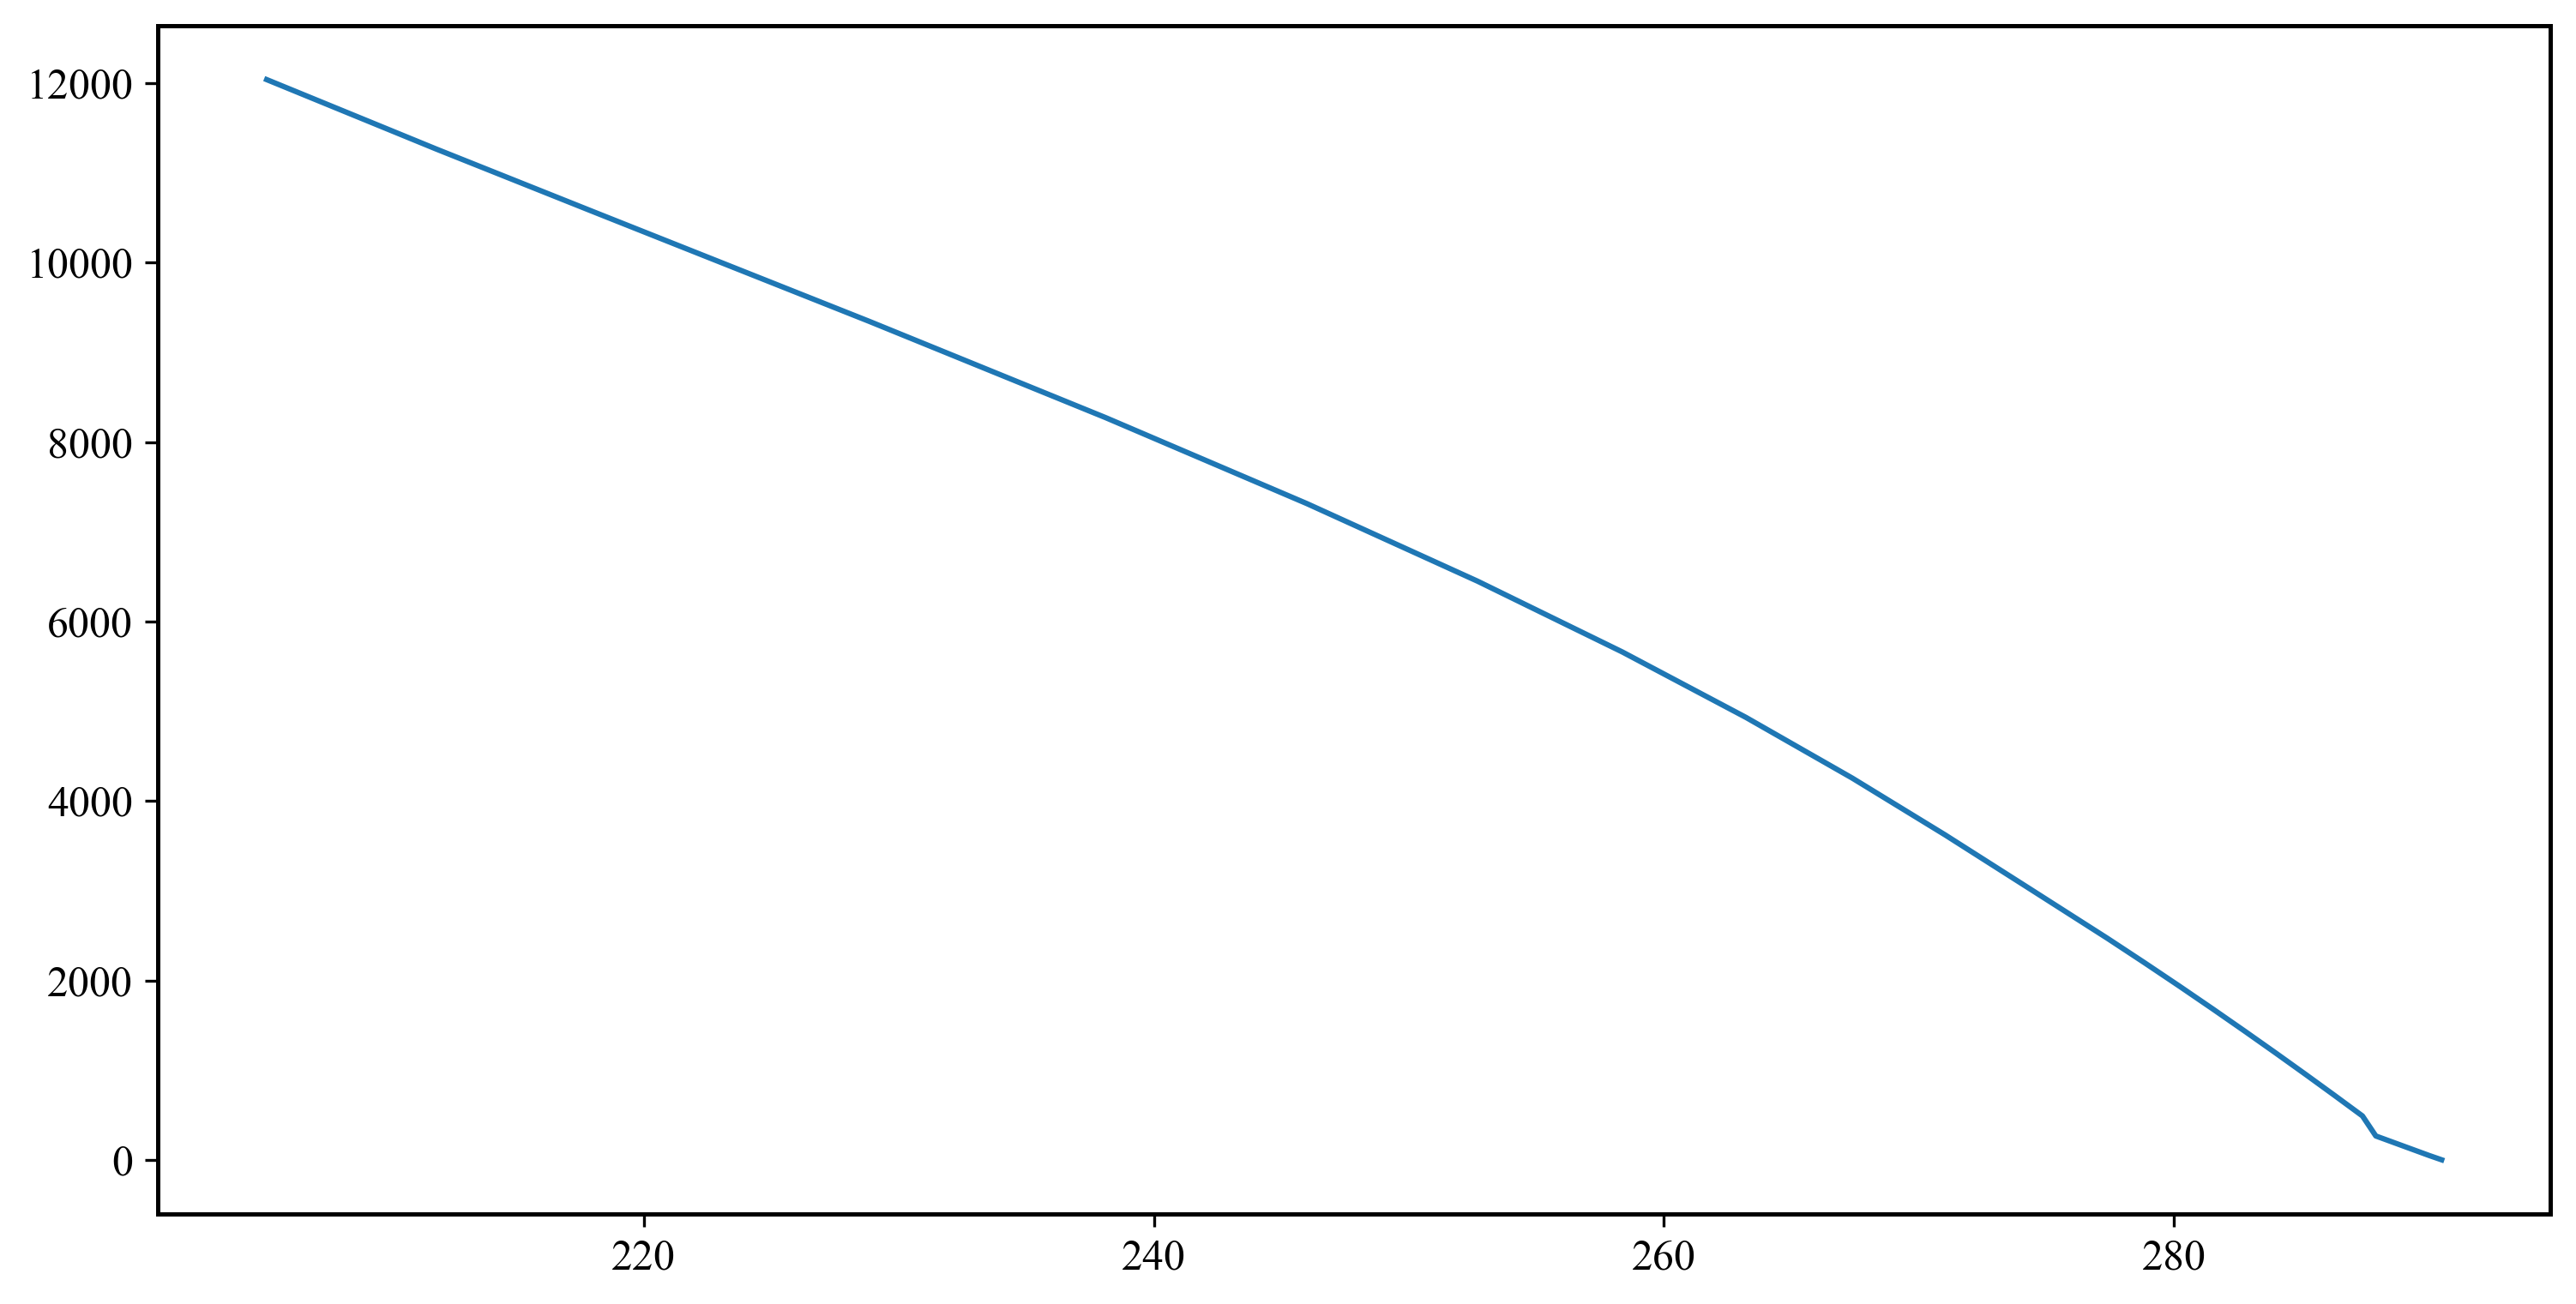

In [58]:
plt.plot(temp_parcel[1],Z[1])
#plt.plot(temp_parcel_new[1],Z_new[1])
plt.show()

In [59]:
print(q_v_air[1],q_v_new[1])    

[1.2107149e-02 1.1396669e-02 1.0845445e-02 9.9990591e-03 8.8889822e-03
 7.7621751e-03 6.7387084e-03 5.9899711e-03 5.6403792e-03 5.4403376e-03
 5.2431412e-03 4.7318796e-03 3.5029147e-03 3.2221524e-03 2.8881035e-03
 1.7653087e-03 8.4570015e-04 5.2009069e-04 3.0781448e-04 1.5999284e-04
 8.7355627e-05 4.4681758e-05 3.1352196e-05 1.8062812e-05] [1.21071488e-02 1.13966689e-02 1.11175971e-02 1.08454451e-02
 9.99905914e-03 8.88898224e-03 7.76217505e-03 6.73870835e-03
 5.98997111e-03 5.64037915e-03 5.44033758e-03 5.24314120e-03
 4.73187957e-03 3.50291468e-03 3.22215236e-03 2.88810348e-03
 1.76530867e-03 8.45700153e-04 5.20090689e-04 3.07814480e-04
 1.59992836e-04 8.73556273e-05 4.46817576e-05 3.13521959e-05
 1.80628122e-05]


### Cloud Heights

#### Determining the Location of the LFC

This step calculates the **Level of Free Convection (LFC)**, indicated by the `lfc_index`. The goal is to determine whether the parcel can reach the LFC based on its thermodynamic state.

- If the conditions allow the parcel to become positively buoyant and reach the LFC, the first entry of the `LFC_index` variable is marked as `"yes"` and a value of `1` is stored.
- If the parcel cannot reach the LFC, the entry is marked as `"no"` and a value of `0` is stored.

This check ensures the model accurately tracks whether convection is initiated in each timestep.


In [60]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index
cin_arr = np.zeros(rows)
for i in range(0,rows):
    flag, lfc_idx,cin_arr[i] = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

In [ ]:
CIN

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 4.02126986, 0.        , 0.        ,
       0.        , 0.        , 0.        , 2.17175808, 2.70880131,
       0.        , 0.        , 0.        , 5.06887511, 3.98588347,
       9.14194136, 0.        , 0.        , 0.        , 0.        ])

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [62]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel_new[i])

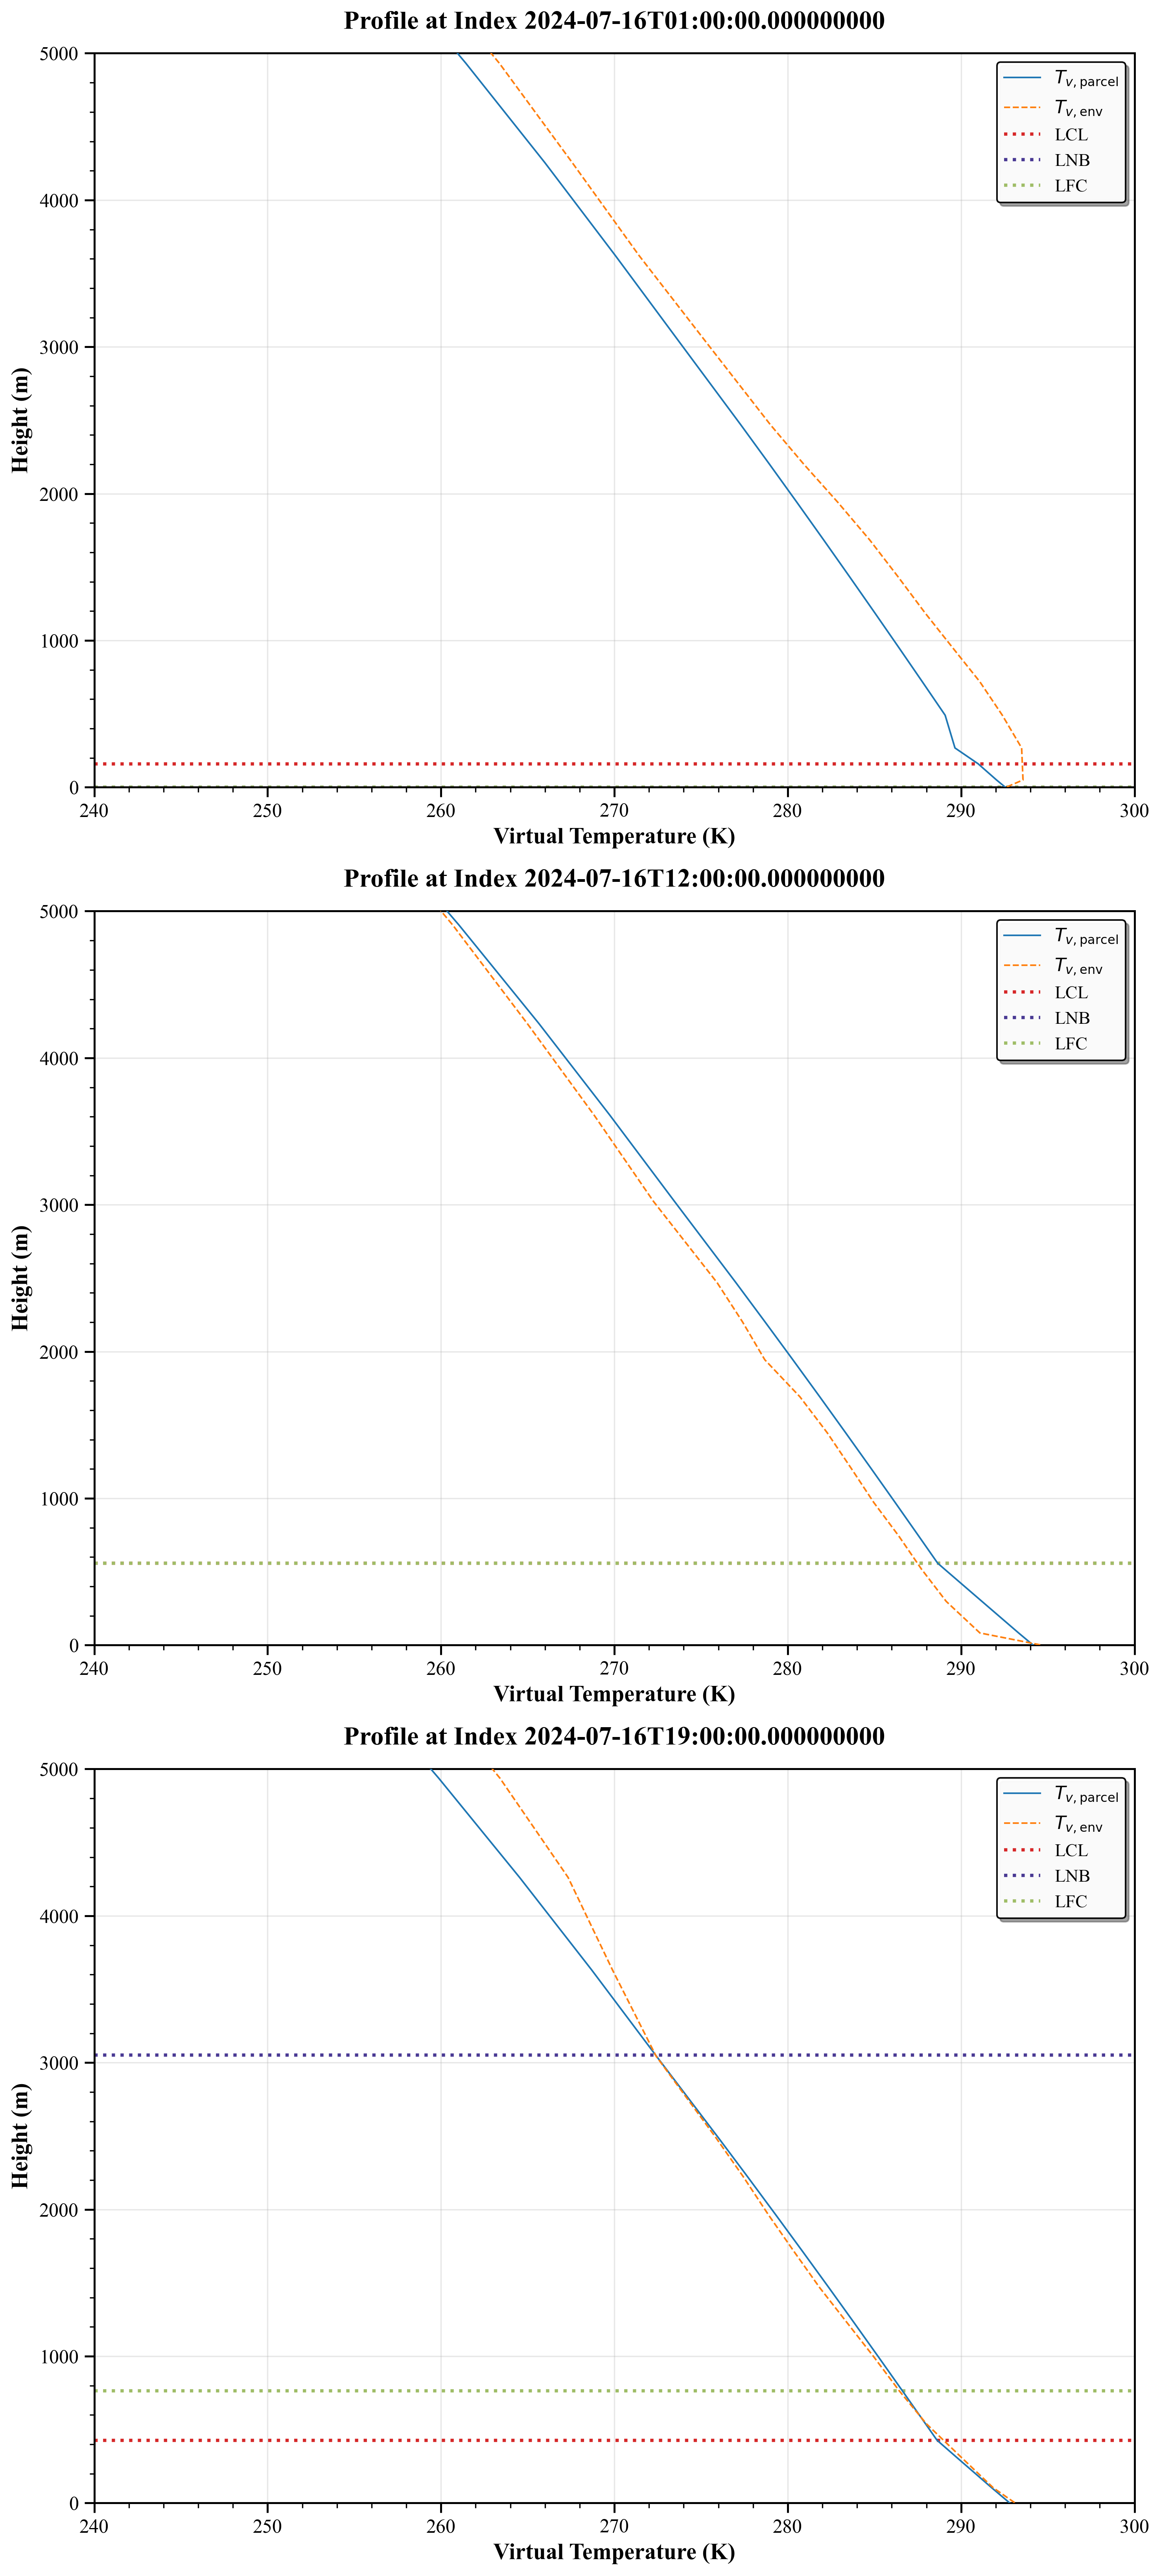

In [63]:
import matplotlib.pyplot as plt

# Set publication-quality style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

# Create 4-panel subplot
fig, axes = plt.subplots(3, 1, figsize=(10, 22))
axes = axes.flatten()

# Define which indices to plot
indices_to_plot = [1, 12, 19]  # Adjust based on your dataset

for i, ax in enumerate(axes):
    index_2 = indices_to_plot[i]

    # Plot virtual temperature of parcel (moist)
    ax.plot(T_v_moist[index_2], Z_new[index_2], 
            label=r'$T_{v,\mathrm{parcel}}$', color='#1f77b4', linewidth=1, zorder=3)

    # Plot environmental virtual temperature
    ax.plot(T_v_env[index_2], Z_new[index_2],
            label=r'$T_{v,\mathrm{env}}$', color='#ff7f0e', linestyle='--', linewidth=1, zorder=3)

    # Add horizontal lines for LCL, LNB, and LFC
    ax.axhline(y=Z_new[index_2, int(lcl_index[index_2])], 
               color='#d62728', linestyle=':', linewidth=2, label='LCL', alpha=1, zorder=2)
    ax.axhline(y=Z_t[index_2], 
               color="#1d087a", linestyle=':', linewidth=2, label='LNB', alpha=0.8, zorder=2)
    ax.axhline(y=Z_new[index_2, int(LFC_index[index_2, 1])], 
               color="#9fbd67ff", linestyle=':', linewidth=2, label='LFC', alpha=1, zorder=2)

    # Labels and title
    ax.set_xlabel('Virtual Temperature (K)', fontweight='bold')
    ax.set_ylabel('Height (m)', fontweight='bold')
    ax.set_title(f'Profile at Index {time[index_2].values}', fontweight='bold', pad=15)

    # Styling
    legend = ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True,
                       framealpha=0.95, edgecolor='black', facecolor='white')
    ax.grid(True, alpha=0.3, linewidth=0.8, zorder=1)
    ax.set_axisbelow(True)
    ax.minorticks_on()
    ax.tick_params(which='major', length=6, width=1.2)
    ax.tick_params(which='minor', length=3, width=0.8)

    # Optional: Set axis limits
    ax.set_xlim(240, 300)
    ax.set_ylim(0, 5000)

# Layout adjustment
plt.tight_layout()

# Save the figure
#plt.savefig('virtual_temp_profiles_4panel.png')
#plt.savefig('virtual_temp_profiles_4panel.pdf')

plt.show()

# Reset style
plt.rcParams.update(plt.rcParamsDefault)


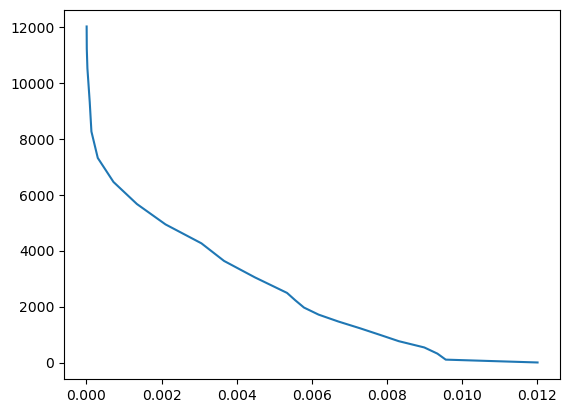

In [64]:
plt.plot(q_v_new[19],Z_new[19])
plt.show()

In [65]:
temp_parcel_new[1]

array([290.49279785, 290.00302863, 288.94847494, 287.91073189,
       287.3873013 , 286.29732345, 285.16834556, 283.99742776,
       282.78130276, 281.51632933, 280.19843811, 278.8230687 ,
       277.38509634, 274.29749927, 271.01504444, 267.37998853,
       263.20930696, 258.36753401, 252.69030134, 245.99426766,
       238.09718531, 228.82788207, 217.98445457, 211.87215209,
       205.20933133])

In [66]:
(1/((T_air[1,0] - T_d[1])/223.15 + 1))* T_air[1,0]

288.87101961379915

### Entrainment calculations

Cell that automatically selects the correct index of cloud height to implement entrainment from, based on the user selection

In [67]:
if entrainment_beginning=='from LCL':
    start_index = lcl_index + 1
elif entrainment_beginning=='from ground':
    start_index = np.ones(lcl_index.shape[0])

Updating the parcel profiles of temperature and humidity, this time taking entrainment into account 

In [68]:
#from profiles_and_cloud_heights import profiles_with_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))
Theta_air = np.zeros((rows,cols+1))
for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
    T_parcel_new[i],q_t_parcel_new[i] = profiles.calculate_profiles_with_entrainment(T_s[i], T_d[i], air_temp_new[i], temp_parcel_new[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(start_index[i]), entrainment_rate, theta_type)


c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\scipy\optimize\_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [69]:
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = 1*q_v_parcel

for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i]) 
    q_l_new[i],q_v_parcel_new[i] = profiles.calculate_humidity_profiles_with_entrainment(q_t_parcel_new[i],p_new[i],T_parcel_new[i],T_d[i],int(start_index[i]))
    
    # if entrainment starts from the ground, then the LCL changes so it has to be recalculated and interpolated
    if entrainment_beginning=='from ground':
        
        temp_parcel[i] = np.delete(T_parcel_new[i],int(lcl_index[i]))
        p_air[i] = np.delete(p_new[i],int(lcl_index[i]))
        Z[i] = np.delete(Z_new[i],int(lcl_index[i]))
        T_air[i] = np.delete(air_temp_new[i],int(lcl_index[i]))
        q_v_air[i] = np.delete(q_v_new[i],int(lcl_index[i]))

        lcl_index[i],T_s[i],p_s[i] = lcl_enrtainment_from_ground(T_parcel_new[i],p_new[i],T_d[i],Z_new[i])
        lcl_index[i] = np.clip(int(lcl_index[i]), 0, len(p_air[i]) - 3)     #for cases where the LCL is in very high altitude

        #interpolation at the lcl level
        T_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])
    



Calculating the new parcel virtual temperature profile after considering entrainment 

In [70]:
if theta_type=='theta_e' or theta_type=='GB84':
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new)
else:
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new- q_l_new)

#### LFC height

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [71]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx,CIN = profiles.find_lfc_level(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [72]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

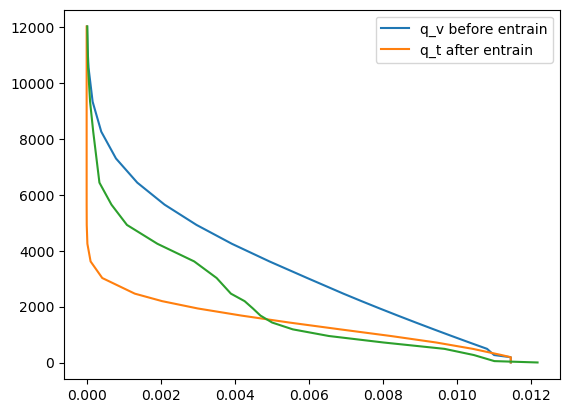

In [73]:
index = 2
plt.plot(q_v_parcel[index],Z_new[index],label='q_v before entrain')
#plt.plot(q_v_parcel[index],Z_new[index])
#plt.plot(q_v_new[index],Z_new[index])
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_t after entrain')
plt.plot(q_v_new[index],Z_new[index])
#plt.plot(q_v_parcel_new[index],Z_new[index])
#plt.plot(q_l_new[index],Z_new[index])
#plt.axhline(y=Z_new[index,int(lcl_index[index+1])],color='blue')
#plt.axhline(y=Z_t[index],color='green')
#plt.axhline(y=Z_t_new[index],color='red')
plt.legend()
plt.show()

In [74]:
def find_top_index(Z_t_new,Z_c_new,Z_new):
    if Z_t_new == 0 or Z_c_new == 1:  
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new - Z_new) <= 0)
    return top_index

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel **updraft velocity profile** by calling the `updraft_emmanuel.py`. To do so, we have to first find the index of cloud top height. 

In [75]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(Z_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],top_index)

In [76]:
n_nans = np.isnan(q_t_parcel_new).sum()
print(f"Number of NaNs in q_l_new: {n_nans}")

Number of NaNs in q_l_new: 0


### State calculation and update

#### Calculating the Temporal Evolution of the Cloud System

This section computes the **state evolution of the cloud system over time**. The evolution focuses on changes in cloud liquid water content due to condensation and precipitation processes.

**Components of the Moisture Budget**

- *Condensation (Inflow)*  
  The amount of condensed water within the cloud is calculated using the `GB84.py` module, based on the approach of Georgakakos and Bras (1984).

- *Outflow (Losses)*  
  Moisture outflow from the cloud includes:
  - *Rainwater formation*: Determined via the `autoconversion_rate.py` module, which estimates the rate at which cloud water is converted to rain.
  - *Droplet removal by updrafts*: Handled by the `top_outflow.py` module, representing the loss of cloud droplets entrained by upward-moving air.

Together, these components allow the model to track the cloud water budget and estimate precipitation over time.


In [77]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])  

    w_avg = w_parcel_max[i]/2
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = condensation_fluxes.condensation_flux(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index,theta_type=theta_type)

    if i<rows-1:
    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i]# - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])

In [78]:
f_arr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00110216,
       0.01185006, 0.01685784, 0.00739345, 0.        , 0.00202534,
       0.00562279, 0.00855846, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [79]:
total_water = np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    if theta_type == "GB84" or theta_type == "theta_e":         #in pseudoadiabatic approach water is constantly removed, 
        total_water[i] = np.sum(q_l_new[i,int(lcl_index[i]):int(top_index)+1])                                                   #so integrate over all cloud heights
    
    else:                                                       #in reversible approach water is staying inside the parcel,
        total_water[i] = q_l_new[i,int(top_index)]                                                  #so total water is what reaches the cloud top

In [80]:
np.mean(total_water)

0.0006842278320237058

### Rainfall rates

#### Precipitation Rate Calculation at Ground Level

The process to calculate the precipitation rate reaching the ground involves multiple steps:

- **Rainfall Rate from Cloud:**  
   The initial rate of rainfall exiting the cloud is determined by executing the script `autoconversion_rate.py`.

- **Rain Droplet Size Distribution:**  
   Using the calculated rainfall rate, the script `new_rainfall_scheme.py` assumes and computes a raindrop size distribution.

- **Estimation of Surface Precipitation:**  
   Based on the droplet size distribution, the model estimates the fraction of raindrops that survive evaporation during their descent and subsequently reach the ground as precipitation.


In [81]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    #print(i)
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    R[i] = ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(T_parcel_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

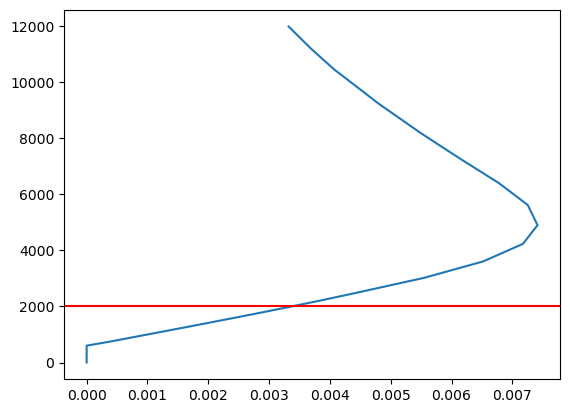

In [82]:
index_max = np.argmax(Z_t_new)
plt.plot(q_l_new[index_max],Z_new[index_max])
#plt.plot(q_v_parcel[index_max],Z_new[index_max])
#plt.plot(q_v_parcel_new[index_max],Z_new[index_max])
plt.axhline(y=Z_t_new[index_max],color='red')
#plt.axhline(y=Z_new[index_max,int(LFC_index[index_max,1])],color='green')
plt.show()

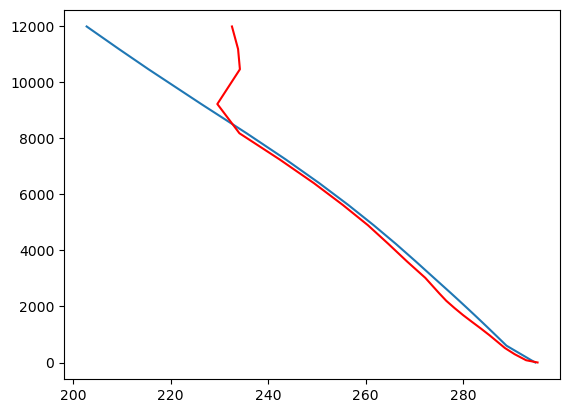

In [83]:
plt.plot(T_v_moist[index_max],Z_new[index_max])
#plt.plot(T_v_moist_new[index_max],Z_new[index_max])
plt.plot(T_v_env[index_max],Z_new[index_max],color='red')
plt.show()

## Visualizing the outputs

#### Rainfall rate

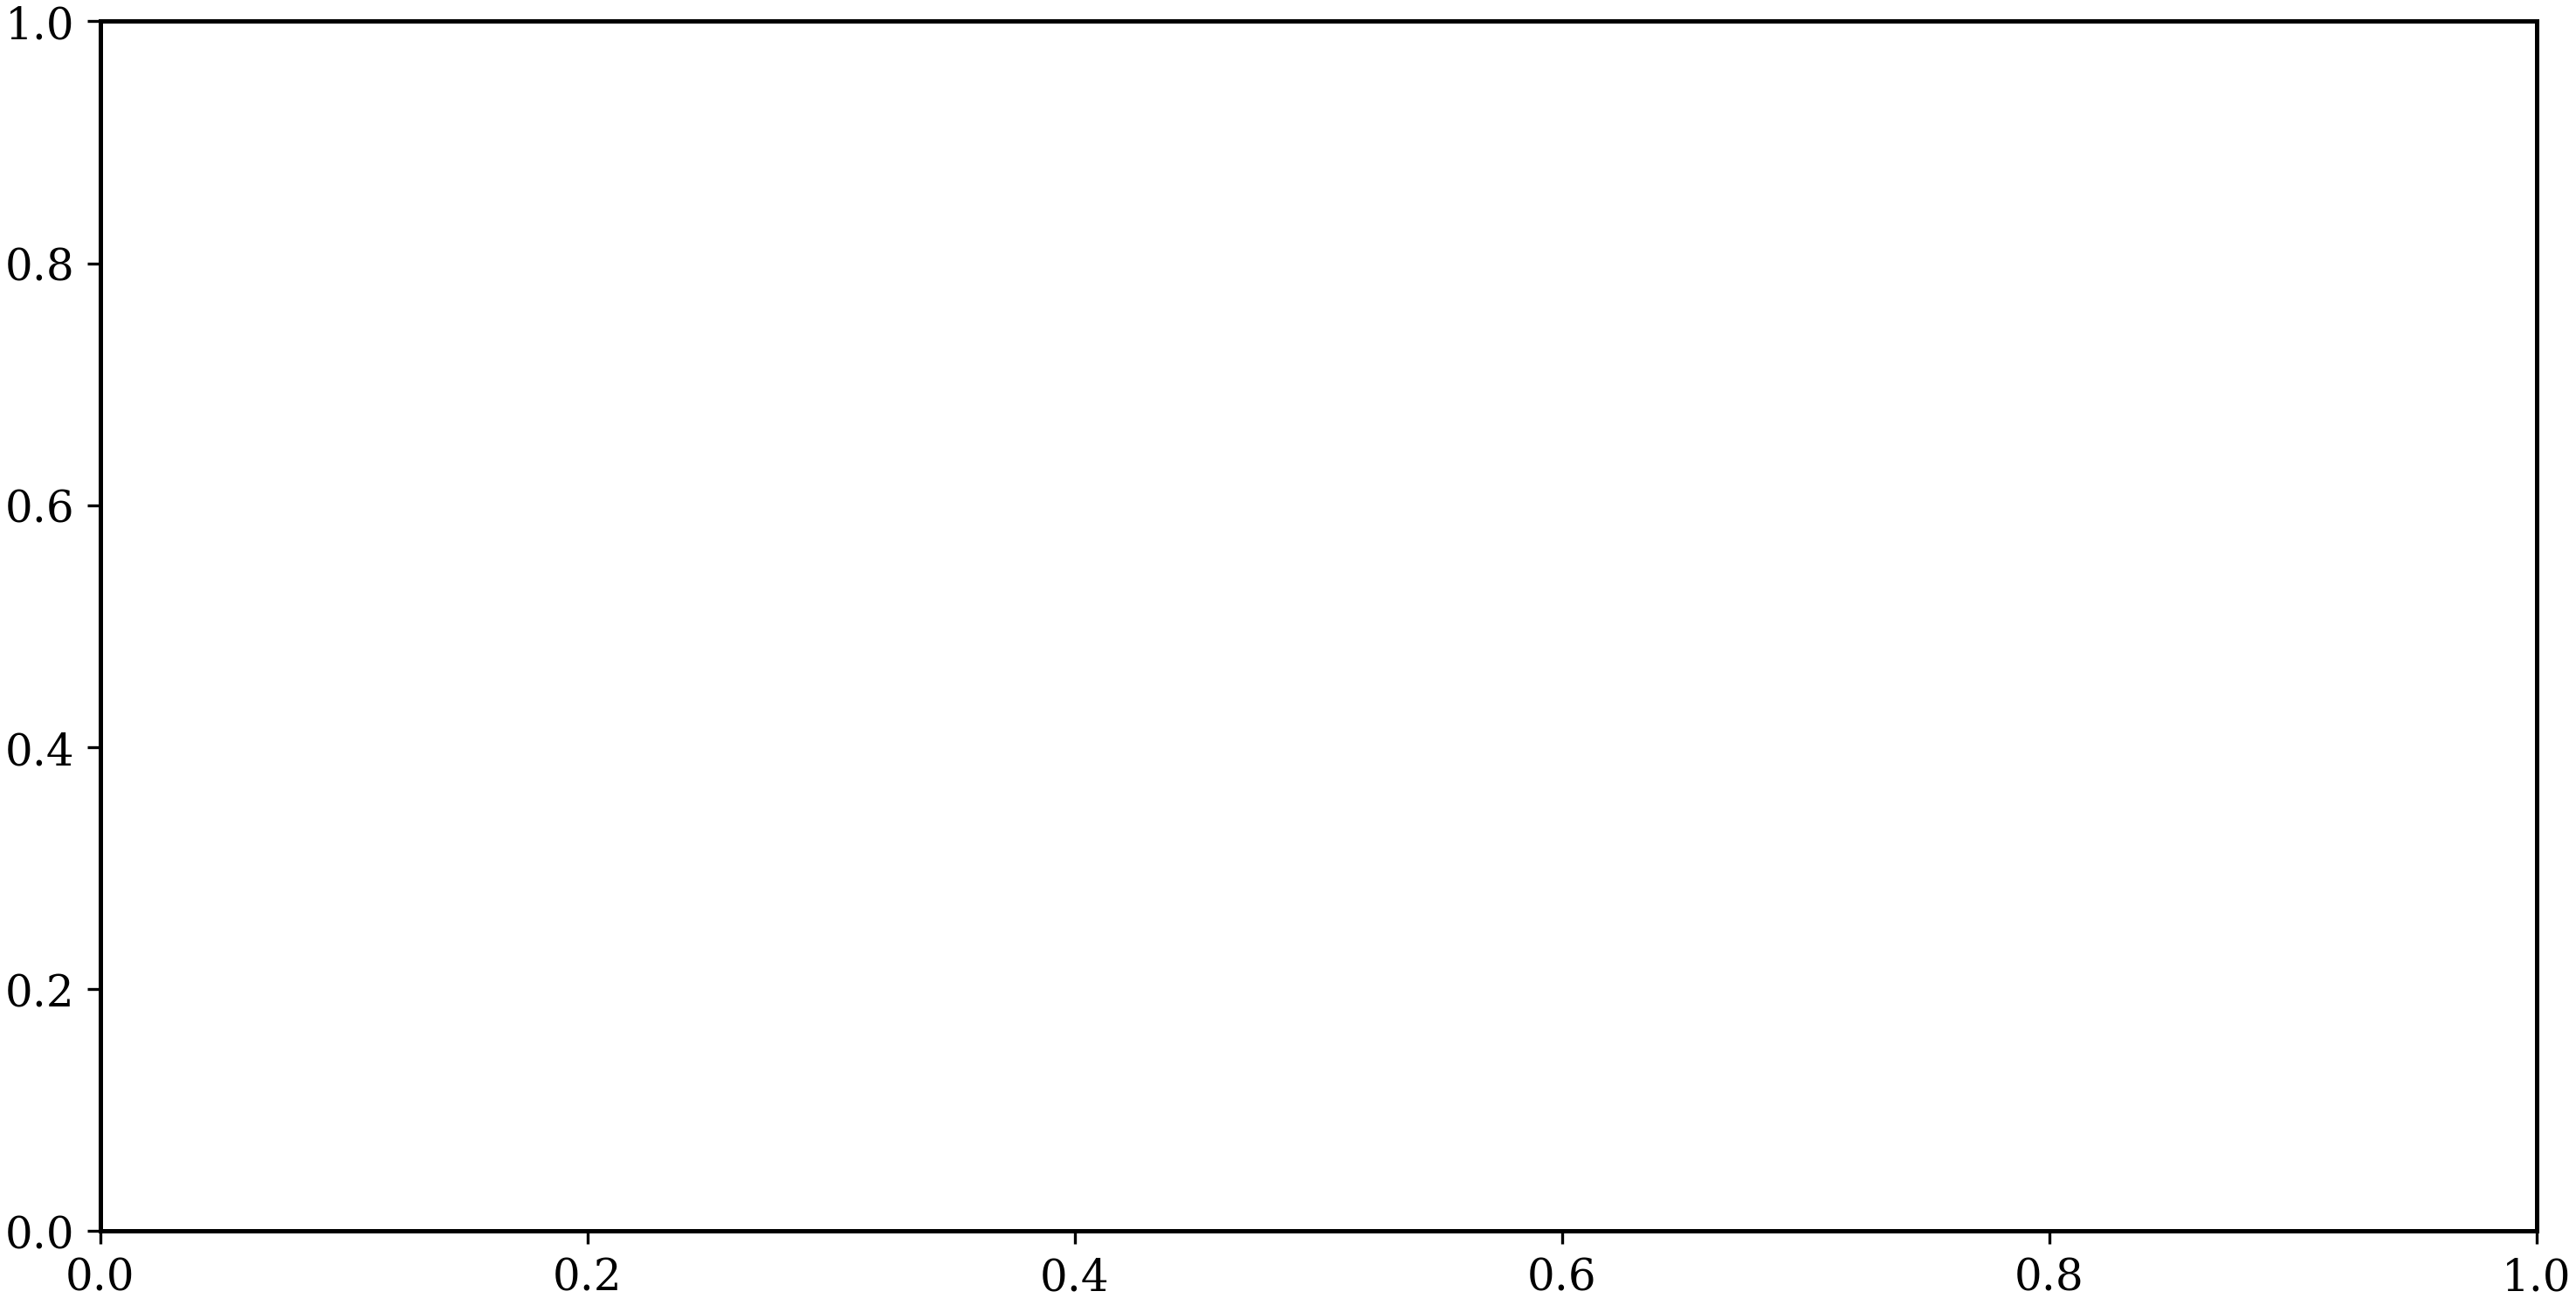

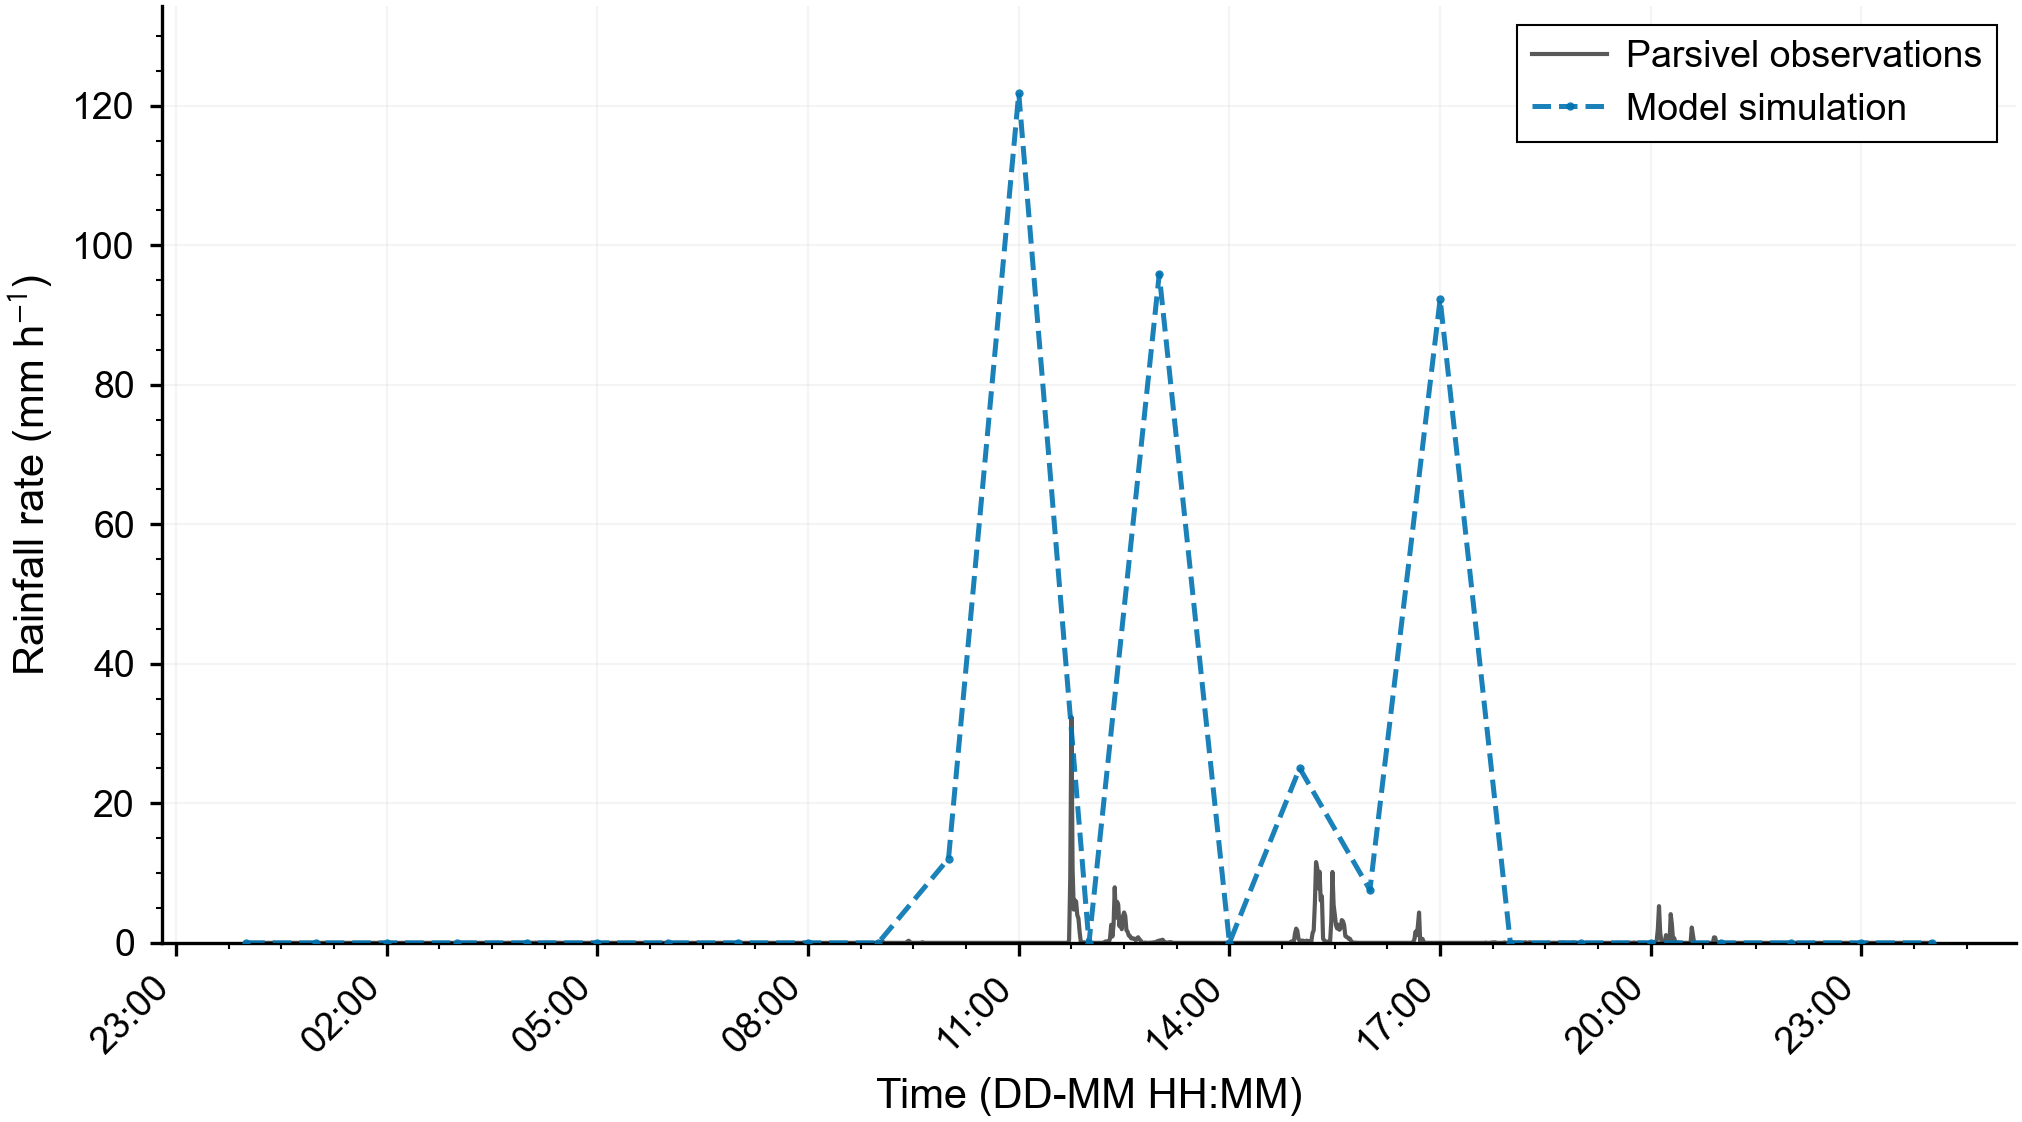

Figure dimensions: 7.0" × 4.0"
Recommended caption: Figure X. Comparison of observed rainfall rates from Parsivel disdrometer
and simulated precipitation from ERA5-based model runs. Observations show...


In [88]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - enhanced for Nature/Science standards
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications (Nature/Science standards)
    'font.size': 10,  # Base font size (don't scale - use absolute values)
    'font.family': 'sans-serif',  # Sans-serif preferred for most journals
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'mathtext.fontset': 'stixsans',  # Consistent math fonts
    'text.usetex': False,  # Generally avoid LaTeX for compatibility
    
    # Axes settings - publication standard
    'axes.linewidth': 0.8,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'axes.labelweight': 'normal',  # Avoid bold in publication plots
    'axes.titleweight': 'normal',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'axes.axisbelow': True,  # Grid below data
    
    # Tick settings - precise and clean
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'out',  # Standard scientific convention
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'xtick.minor.size': 1.5,
    'ytick.major.size': 3,
    'ytick.minor.size': 1.5,
    'xtick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.major.width': 0.8,
    'ytick.minor.width': 0.5,
    
    # Legend settings - clean and unobtrusive
    'legend.fontsize': 9,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'legend.frameon': True,
    'legend.shadow': False,
    'legend.numpoints': 1,
    'legend.scatterpoints': 1,
    
    # Line settings - publication quality
    'lines.linewidth': 1.2,
    'lines.markersize': 3,
    'lines.markeredgewidth': 0,
    
    # Figure quality - high resolution
    'figure.dpi': 300,
    'figure.facecolor': 'white',
    'figure.edgecolor': 'none',
    'savefig.dpi': 600,  # High DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'savefig.format': 'pdf',  # Vector format preferred
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'none',
})

# Create figure with publication-standard dimensions
# Single column: 3.5 inches, Double column: 7 inches (Nature standards)
fig_width = 7.0 * SCALE_FACTOR  # Double column width
fig_height = 4.0 * SCALE_FACTOR  # Golden ratio approximation
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Scientific color palette - colorblind-friendly and publication-ready
colors = {
    'parsivel': '#2E2E2E',     # Dark grey (observations)
    'model': '#0173B2',        # Professional blue (model)
    'accent': '#CC78BC',       # Optional accent color
}

# Enhanced line styles with publication standards
line_parsivel = ax.plot(rain_rate.time, rain_rate, 
                       color=colors['parsivel'], 
                       label='Parsivel observations',  # More descriptive
                       linewidth=1.0,  # Thinner for observations
                       alpha=0.8,
                       zorder=2)  # Control layer order

line_model = ax.plot(time, R * 3600, 
                    color=colors['model'], 
                    linestyle='--', 
                    label='Model simulation',  # More descriptive
                    linewidth=1.2,
                    marker='o',
                    markersize=2,
                    markerfacecolor=colors['model'],
                    markeredgecolor='none',
                    alpha=0.9,
                    zorder=3)  # Model on top

# Professional axis labels - no bold, clear units
ax.set_xlabel('Time (DD-MM HH:MM)')
ax.set_ylabel('Rainfall rate (mm h$^{-1}$)')

# Title handling - many journals prefer no title or caption-style
# ax.set_title('Comparison of observed and simulated rainfall rates', pad=10)

# Professional grid - subtle and unobtrusive
ax.grid(True, alpha=0.2, linewidth=0.5, color='#CCCCCC', zorder=0)

# Enhanced tick management
ax.minorticks_on()

# Y-axis formatting - clean scientific notation when needed
ax.ticklabel_format(style='plain', axis='y', useOffset=False)

# Enhanced date formatting with better spacing
def setup_time_axis(ax, time_data, scale_factor):
    """Setup time axis with publication-quality formatting"""
    
    # Handle different time data types (xarray, pandas, datetime)
    try:
        # For xarray DataArray
        if hasattr(time_data, 'values'):
            time_values = time_data.values
        else:
            time_values = time_data
            
        # Convert to pandas datetime if needed
        if hasattr(time_values, 'dtype') and 'datetime64' in str(time_values.dtype):
            import pandas as pd
            time_pd = pd.to_datetime(time_values)
            time_range_hours = (time_pd[-1] - time_pd[0]).total_seconds() / 3600
        else:
            # Assume it's already datetime objects
            time_range_hours = (time_values[-1] - time_values[0]).total_seconds() / 3600
            
    except (AttributeError, IndexError):
        # Fallback - use default formatting
        time_range_hours = 48  # Assume 2 days as default
    
    # Determine optimal tick spacing based on data range
    if time_range_hours <= 24:  # Less than a day
        major_interval = 3
        date_format = '%H:%M'  # 24-hour format
    elif time_range_hours <= 72:  # Less than 3 days
        major_interval = 6
        date_format = '%d/%m %H:%M'  # 24-hour format with date
    else:  # Longer periods
        major_interval = 12
        date_format = '%d/%m %Hh'  # 24-hour format, hours only
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=major_interval))
    
    # Rotate labels for better readability
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Setup time axis - pass the time data
setup_time_axis(ax, time, SCALE_FACTOR)

# Publication-quality legend
legend = ax.legend(
    loc='upper right',
    frameon=True,
    framealpha=1.0,
    edgecolor='black',
    facecolor='white',
    handlelength=2.0,
    handletextpad=0.5,
    columnspacing=1.0,
    ncol=1
)

# Set legend frame linewidth separately
legend.get_frame().set_linewidth(0.5)

# Set axis limits with some padding for publication clarity
y_min, y_max = ax.get_ylim()
ax.set_ylim(0, y_max * 1.05)  # Start from 0, add 5% padding on top

# Optional: Add statistical information as text box
# stats_text = f'Max observed: {np.max(rain_rate):.1f} mm/h\nMax simulated: {np.max(R * 3600):.1f} mm/h'
# ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
#         verticalalignment='top', fontsize=8, 
#         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Ensure proper spacing and layout
plt.tight_layout()

# Professional save options with multiple formats
def save_publication_figure(filename_base):
    """Save figure in multiple publication-ready formats"""
    formats = ['pdf', 'png', 'eps']  # Common journal requirements
    
    for fmt in formats:
        filename = f"{filename_base}.{fmt}"
        plt.savefig(filename, 
                   format=fmt, 
                   dpi=600 if fmt == 'png' else 300,
                   bbox_inches='tight',
                   pad_inches=0.02,
                   facecolor='white',
                   edgecolor='none')
        print(f"Saved: {filename}")

# Show the plot
plt.show()

# Uncomment to save in publication formats
# save_publication_figure('rainfall_comparison_era5')

# Reset matplotlib parameters to defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Print figure information for manuscript
print(f"Figure dimensions: {fig.get_size_inches()[0]:.1f}\" × {fig.get_size_inches()[1]:.1f}\"")
print(f"Recommended caption: Figure X. Comparison of observed rainfall rates from Parsivel disdrometer")
print(f"and simulated precipitation from ERA5-based model runs. Observations show...")

In [85]:
import pickle
import pandas as pd
import numpy as np
from datetime import datetime

# Method 1: Save as pickle (preserves exact Python objects including datetime)
def save_datasets_pickle():
    """Save all datasets as pickle files"""
    datasets = {
        'rain_rate': rain_rate,
        'time': time,
        'R': R,
        'Z_t': Z_t,
        'Z_t_new': Z_t_new,
        'metadata': {
            'theta_type': theta_type,
            'entrainment_beginning': entrainment_beginning,
            'slice_str': slice_str,
            'slice_tuple': slice_tuple,
            'start_dt': start_dt,
            'end_dt': end_dt,
            'save_timestamp': datetime.now().isoformat()
        }
    }
    
    with open('era5_datasets.pkl', 'wb') as f:
        pickle.dump(datasets, f)
    
    print("✓ Datasets saved as era5_datasets.pkl")

In [86]:
save_datasets_pickle()

✓ Datasets saved as era5_datasets.pkl


In [87]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'hourly_avg': '#1f77b4',     # Blue
    'model': '#ff7f0e',          # Orange
}

# Plot with scaled line widths
ax.plot(time_dt, hourly_avg,
        color=colors['hourly_avg'], 
        label='Hourly average Parsivel 1',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

ax.plot(time_dt, R * 3600,
        color=colors['model'], 
        label='Model precipitation',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Precipitation rate (mm/h)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Precipitation Comparison: Observations vs Model',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper right',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

NameError: name 'hourly_avg' is not defined

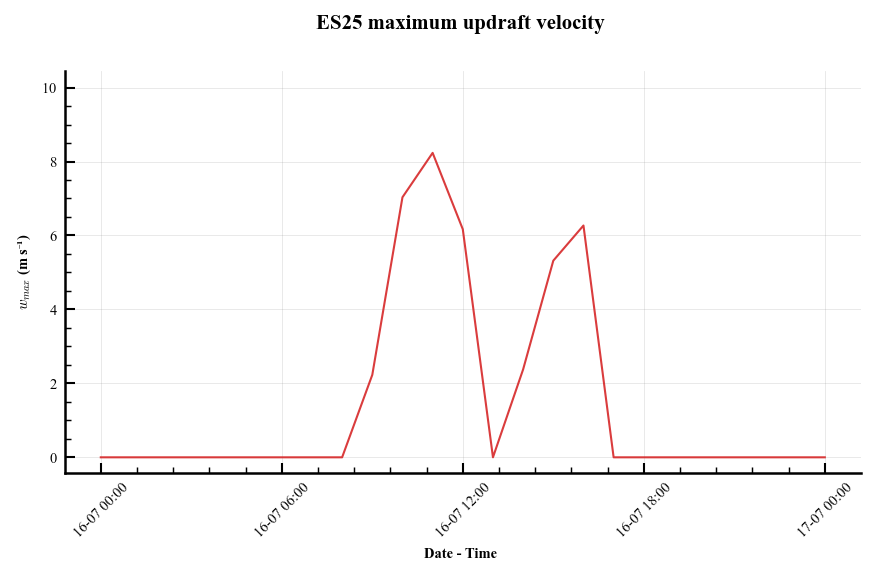

In [93]:

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 7,
    'axes.titlesize': 10,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 7,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(6, 4))
#ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
##ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#29160689",           # Orange
}

# Plot water fluxes on left axis (ax1)

# Plot updraft velocity on right axis (ax2)
line4 = ax1.plot(time, w_parcel_max, 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                alpha=0.9)
#ax1.hlines(y=np.min(X[mask]), xmin=time[mask].min(), xmax=time[mask].max(),)
# Set updraft velocity y-axis to start from 0 and leave space at top

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()


ax1_range = ax1_ylim[1] - ax1_ylim[0]


ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)


# ADD PRECIPITATION SHADING HERE
# Get updated y-limits after extension for proper shading
y_min, y_max = ax1.get_ylim()

# Add red shaded areas for precipitation
# Assuming you have P*3600 and rain_rate variables
mask = (P[0]*3600 > 0.25).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.25)  # Handle xarray
#mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)


# Optionally add shading for actual rain rate with different color/alpha
#ax1.fill_between(time, y_min, y_max, where=mask_actual,
                 #alpha=0.2, color='orange', label='Rain rate > 0.2 mm/h', interpolate=True)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('$w_{max}$ (m s⁻¹)', color='black', fontweight='bold')
ax1.set_title('ES25 maximum updraft velocity ', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')


# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)

# Professional y-axis formatting for ax2
#ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#ax2.yaxis.get_offset_text().set_fontsize(11)

# Proper time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    ax1.set_xlabel('Time (min)', fontweight='bold')
    ax1.xaxis.set_major_locator(MultipleLocator(360))
    ax1.set_xlim(left=0)

# Combine legends from both axes AND precipitation shading
lines1, labels1 = ax1.get_legend_handles_labels()


# Scientific legend positioning

# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

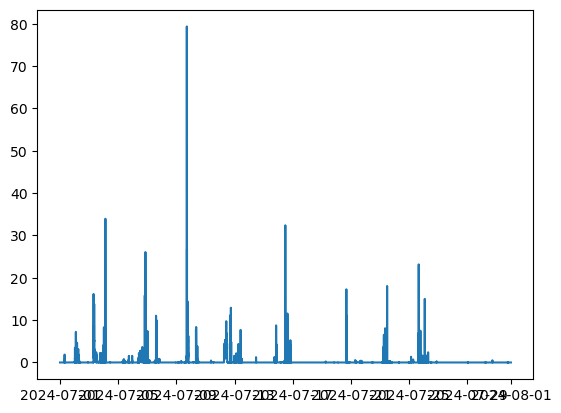

In [ ]:
plt.plot(rain_rate.time, rain_rate)
plt.show()

#### Virtual Temperature profiles at different times

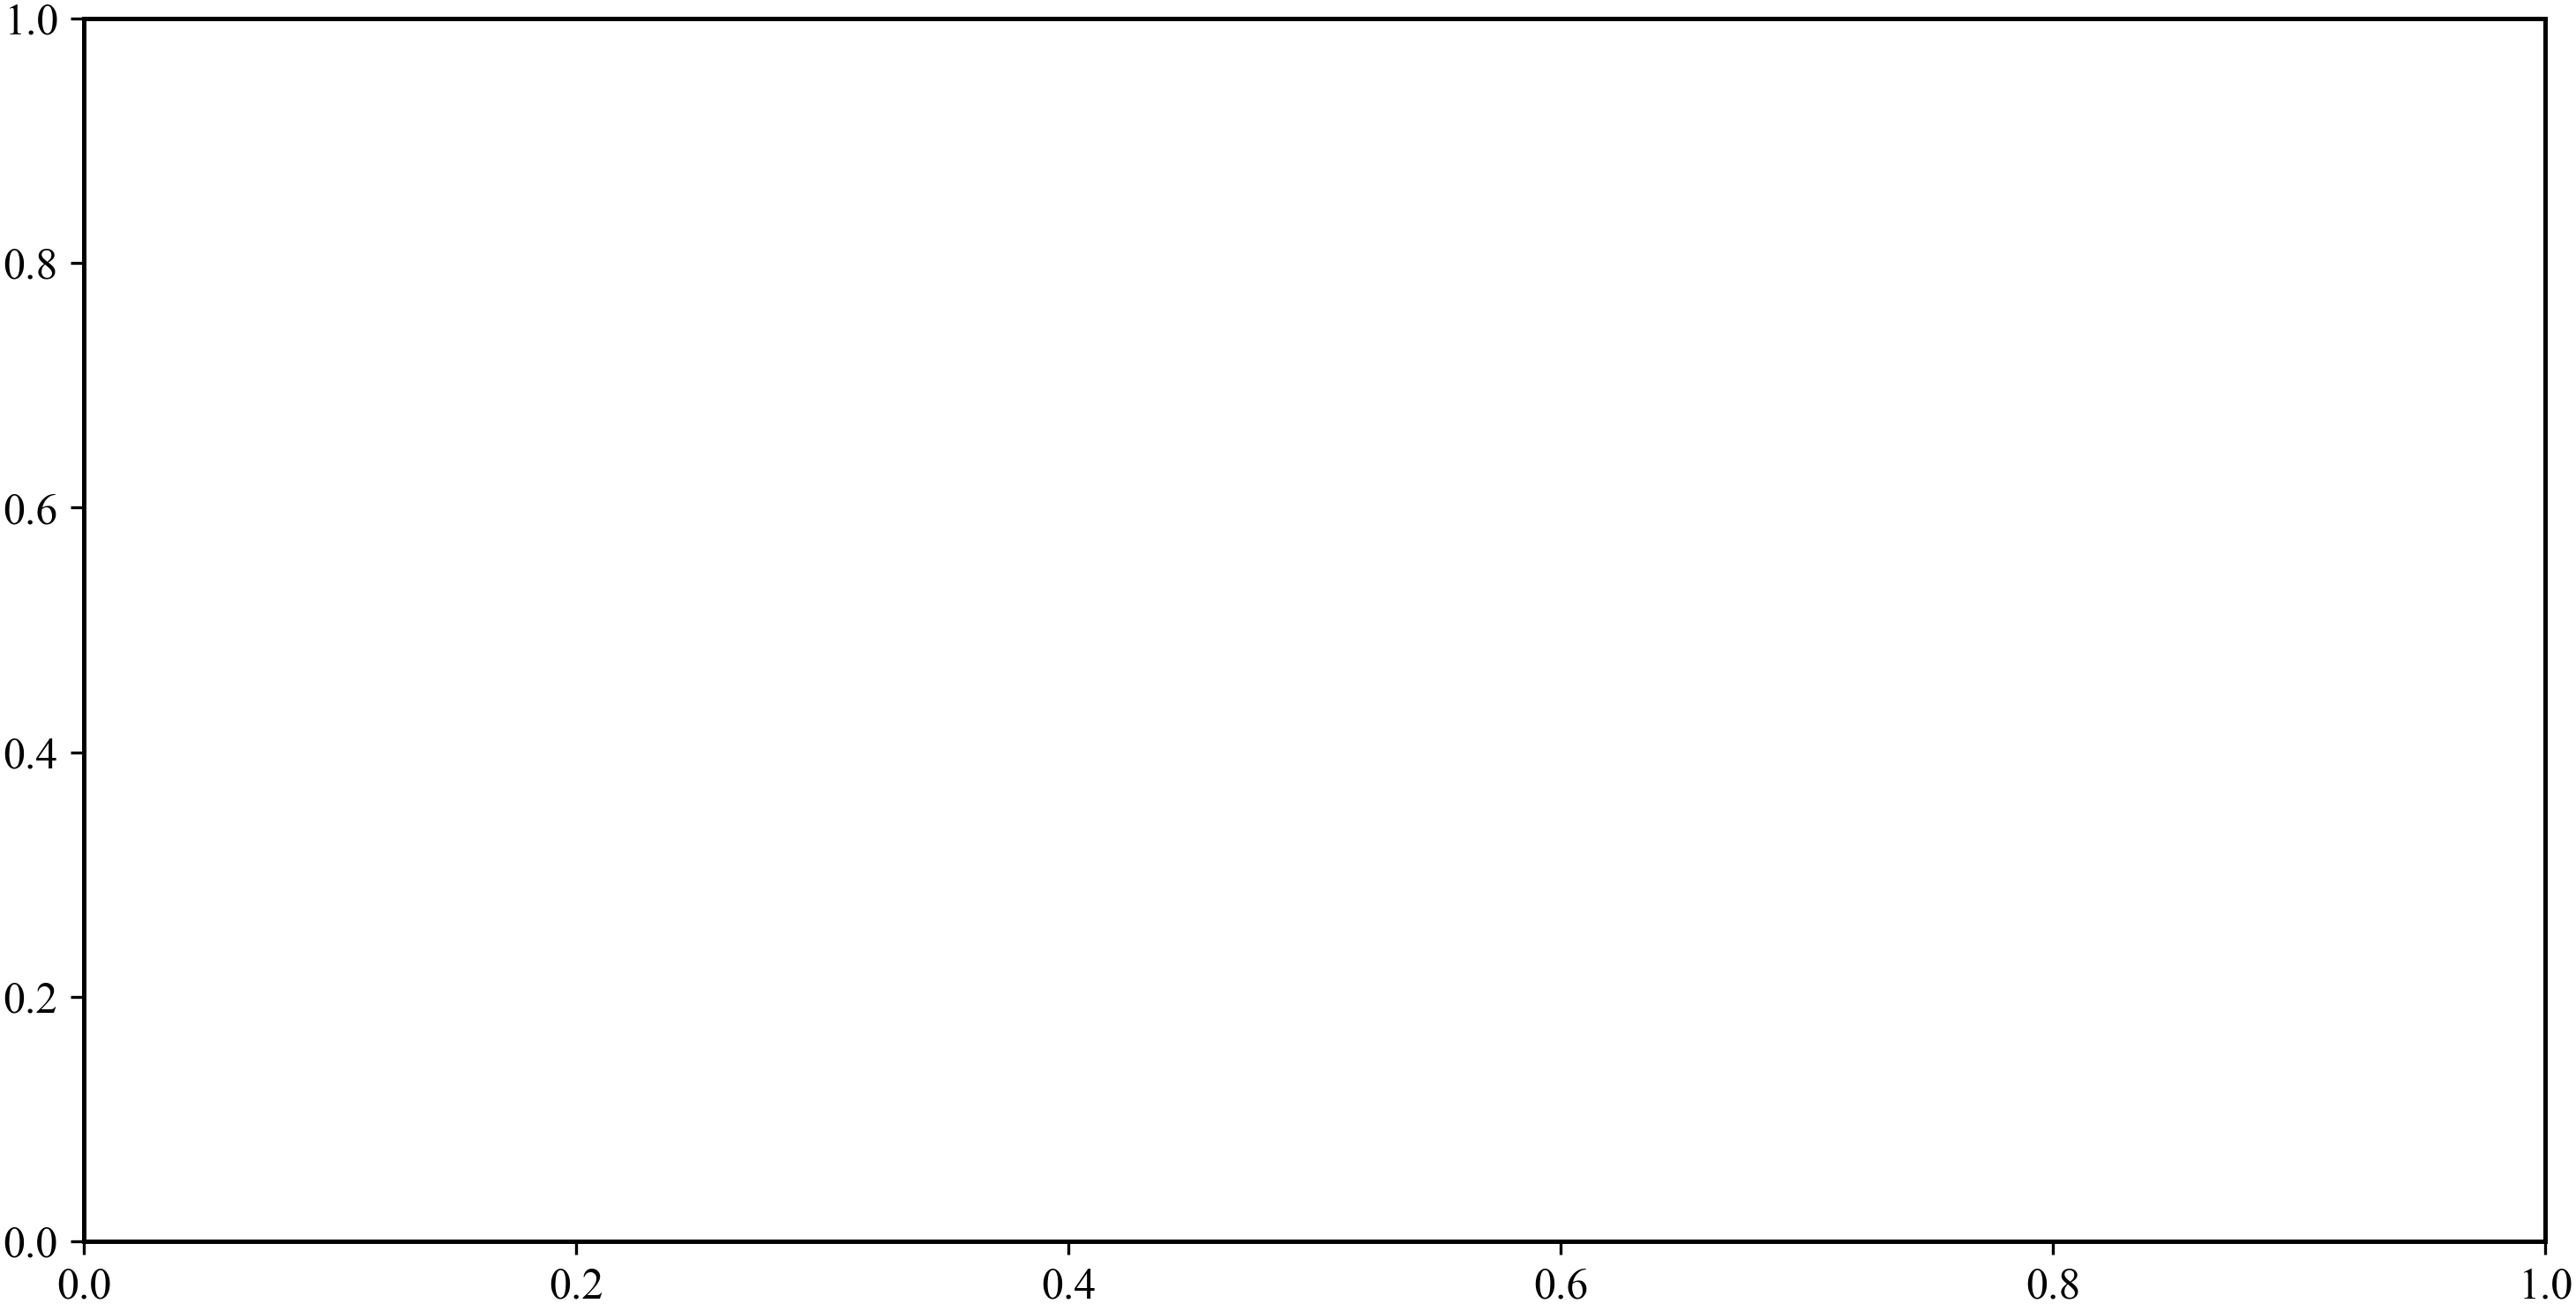

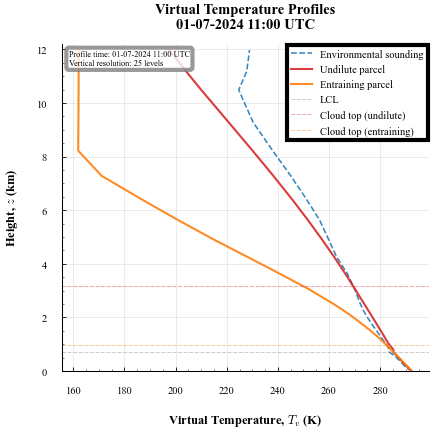

In [ ]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.25  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with scientific aspect ratio - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(6 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient = ax.plot(T_v_env[index_2], Z_new[index_2]/1000,  # Convert to km
                      color=colors['ambient'], 
                      label='Environmental sounding',
                      linestyle='--', 
                      linewidth=1.5 * SCALE_FACTOR,
                      alpha=0.9)

line_dry = ax.plot(T_v_moist[index_2], Z_new[index_2]/1000,
                  color=colors['no_entrainment'], 
                  label='Undilute parcel',
                  linestyle='-', 
                  linewidth=2.0 * SCALE_FACTOR,
                  alpha=0.9)

line_entrain = ax.plot(T_v_moist_new[index_2], Z_new[index_2]/1000,
                      color=colors['with_entrainment'], 
                      label='Entraining parcel',
                      linestyle='-', 
                      linewidth=2.0 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax.set_xlabel('Virtual Temperature, $T_v$ (K)', fontweight='bold')
ax.set_ylabel('Height, $z$ (km)', fontweight='bold')

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')
ax.set_title(f'Virtual Temperature Profiles\n{timestamp_str}',
             fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Add horizontal reference lines with labels - scaled line widths by SCALE_FACTOR
lcl_line = ax.axhline(y=Z_new[index_2,int(lcl_index[index_2])]/1000, 
                     color='grey', linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                     label='LCL')

zt_line = ax.axhline(y=Z_t[index_2]/1000, 
                    color=colors['no_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                    label='Cloud top (undilute)')

zt_new_line = ax.axhline(y=Z_t_new[index_2]/1000, 
                        color=colors['with_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                        label='Cloud top (entraining)')

# Set axis limits with some padding for scientific presentation
temp_range = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
              np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding = (temp_range[1] - temp_range[0]) * 0.05
ax.set_xlim(temp_range[0] - temp_padding, temp_range[1] + temp_padding)

height_max = Z_new[index_2].max()/1000
ax.set_ylim(0, height_max * 1.02)

# Scientific legend positioning - now includes horizontal lines
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)  # Single column for cleaner look

# Add subtle background for better contrast
#ax.set_facecolor('#fafafa')

# Professional tick formatting
ax.ticklabel_format(style='plain', axis='x')
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()

# Optional: Add metadata text box for scientific context - scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8 * SCALE_FACTOR,
        verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

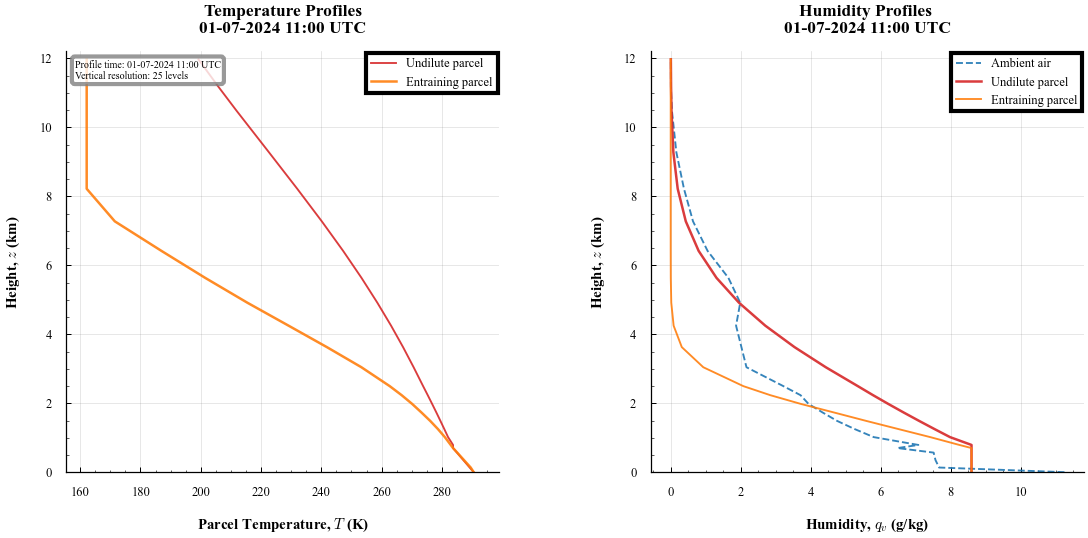

In [ ]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with two subplots side by side - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')

# ===== LEFT SUBPLOT (ax1) =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient1 = ax1.plot(temp_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['no_entrainment'], 
                        label='Undilute parcel', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry1 = ax1.plot(T_parcel_new[index_2], Z_new[index_2]/1000,
                    color=colors['with_entrainment'], 
                    label='Entraining parcel',
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

# Scientific axis labels with units
ax1.set_xlabel('Parcel Temperature, $T$ (K)', fontweight='bold')
ax1.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax1.set_title(f'Temperature Profiles\n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Set axis limits with some padding for scientific presentation
temp_range1 = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
               np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding1 = (temp_range1[1] - temp_range1[0]) * 0.05
ax1.set_xlim(temp_range1[0] - temp_padding1, temp_range1[1] + temp_padding1)

height_max1 = Z_new[index_2].max()/1000
ax1.set_ylim(0, height_max1 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend1 = ax1.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# ===== RIGHT SUBPLOT (ax2) - Duplicate =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient2 = ax2.plot(1000*q_v_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['ambient'], 
                        label='Ambient air',
                        linestyle='--', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry2 = ax2.plot(1000*q_v_parcel[index_2], Z_new[index_2]/1000,
                    color=colors['no_entrainment'], 
                    label='Undilute parcel',
                    linestyle='-', 
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

line_moist = ax2.plot(1000*q_v_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['with_entrainment'], 
                        label='Entraining parcel',
                        linestyle='-', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

# Scientific axis labels with units
ax2.set_xlabel('Humidity, $q_v$ (g/kg)', fontweight='bold')
ax2.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax2.set_title(f'Humidity Profiles \n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Add horizontal reference lines with labels

height_max2 = Z_new[index_2].max()/1000
ax2.set_ylim(0, height_max2 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax2.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting for both subplots
for ax in [ax1, ax2]:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
    
    # Ensure scientific notation if needed
    from matplotlib.ticker import ScalarFormatter
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Adjust spacing manually instead of tight_layout to preserve subplot spacing
plt.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.12, wspace=0.35)

# Optional: Add metadata text box for scientific context - only on left subplot, scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=8 * SCALE_FACTOR,
         verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

#### Cloud top and base

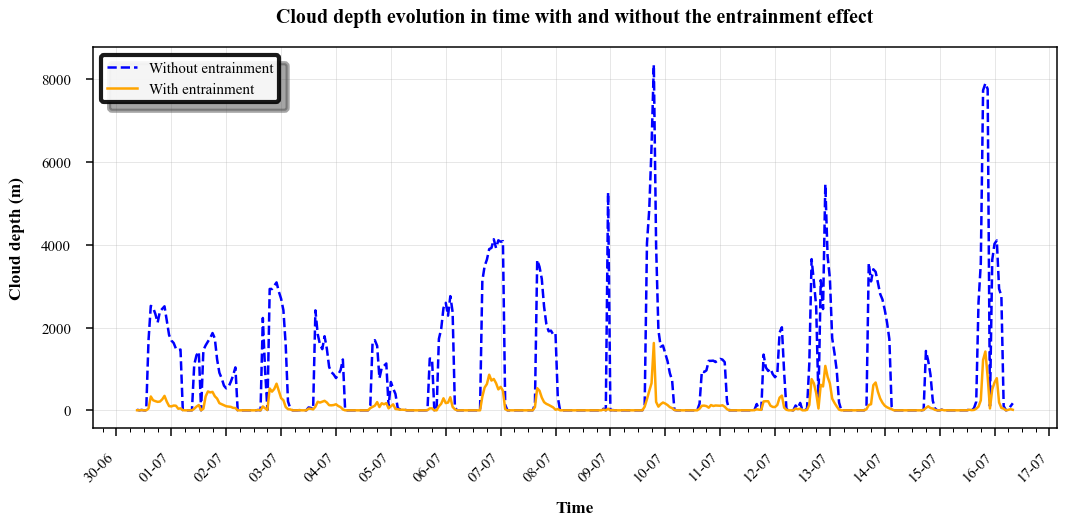

In [ ]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, np.maximum(0, Z_t - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='blue', 
        label='Without entrainment',
        linestyle='--',
        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, np.maximum(0, Z_t_new - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud depth (m)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud depth evolution in time with and without the entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

#### Updraft velocity

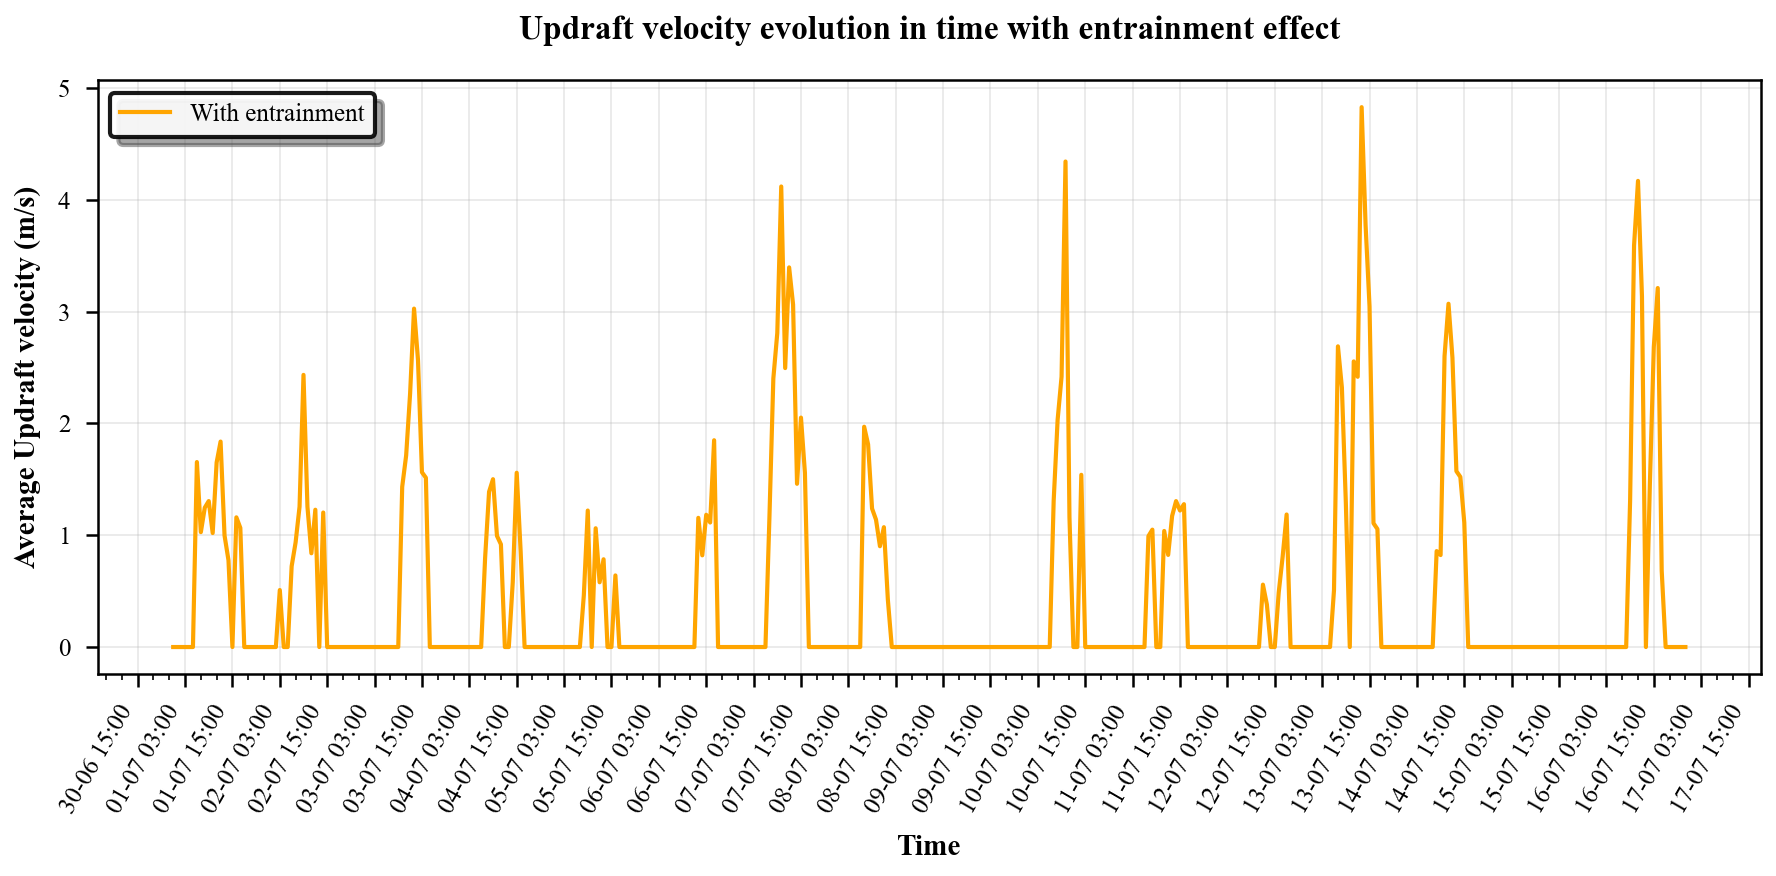

In [ ]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
#ax.plot(time_dt, w_parcel_max_old/2,
#        color='blue', label='Without entrainment', linestyle='--', 
#        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, w_parcel_max/2,
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Average Updraft velocity (m/s)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Updraft velocity evolution in time with entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
indices = np.where(R*3600>0.2)[0]
np.mean(w_parcel_max[indices]/2)

1.3122576435995708

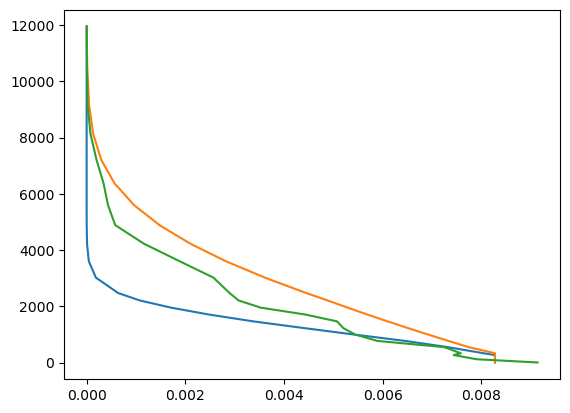

In [ ]:
index = 2
#plt.plot(w_sat(T_d[index],p_new[index,0]) - q_v_parcel[index],Z_new[index],label='T_v_moist')
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_l'   )
plt.plot(q_v_parcel[index],Z_new[index],label='q_v_parcel')
plt.plot(q_v_new[index],Z_new[index],label='q_v')
plt.show()

#### LWC and LWP(state)

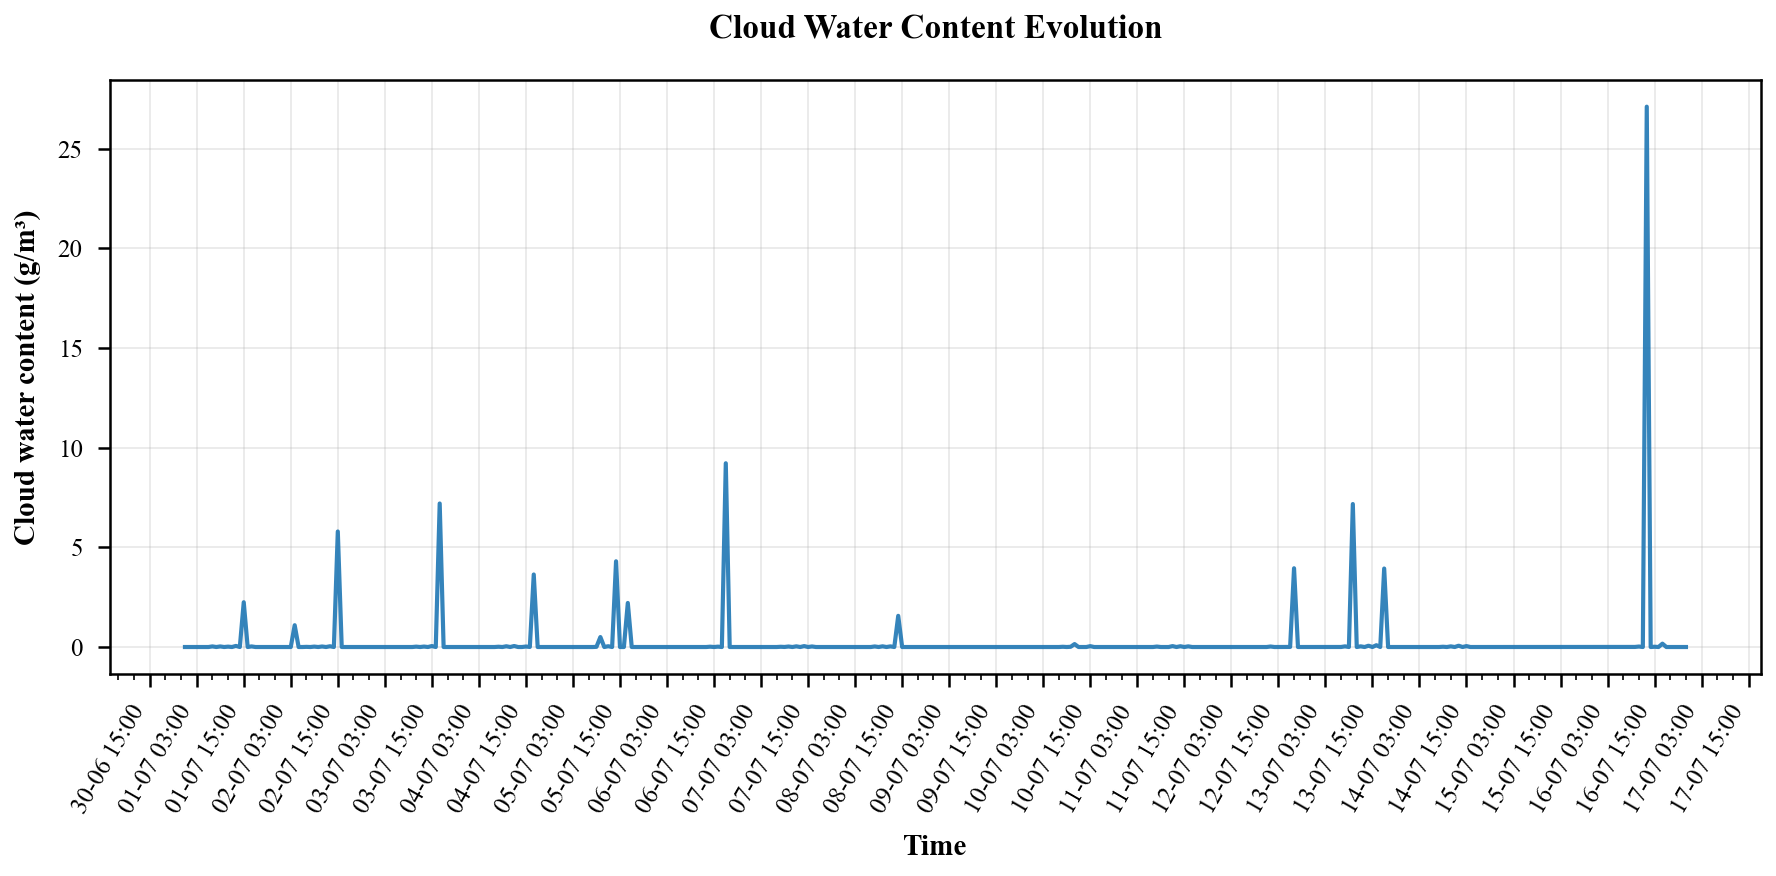

In [ ]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, X / Z_c_new,
        color='#1f77b4',  # Default blue
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud water content (g/m³)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud Water Content Evolution',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Optional: Uncomment to set y-axis limits
#ax.set_ylim(0, 10)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
time_dt

DatetimeIndex(['2024-07-01 00:00:00', '2024-07-01 01:00:00',
               '2024-07-01 02:00:00', '2024-07-01 03:00:00',
               '2024-07-01 04:00:00', '2024-07-01 05:00:00',
               '2024-07-01 06:00:00', '2024-07-01 07:00:00',
               '2024-07-01 08:00:00', '2024-07-01 09:00:00',
               ...
               '2024-07-16 14:00:00', '2024-07-16 15:00:00',
               '2024-07-16 16:00:00', '2024-07-16 17:00:00',
               '2024-07-16 18:00:00', '2024-07-16 19:00:00',
               '2024-07-16 20:00:00', '2024-07-16 21:00:00',
               '2024-07-16 22:00:00', '2024-07-16 23:00:00'],
              dtype='datetime64[ns]', length=384, freq=None)

In [ ]:
from scipy import stats
stats.pearsonr(R*3600, hourly_avg)

NameError: name 'hourly_avg' is not defined

In [ ]:
from scipy import stats
stats.pearsonr(R*3600, hourly_acc)

PearsonRResult(statistic=-0.006824955459807457, pvalue=0.8939507416561414)

In [ ]:
time_dt

DatetimeIndex(['2024-07-01 00:00:00', '2024-07-01 01:00:00',
               '2024-07-01 02:00:00', '2024-07-01 03:00:00',
               '2024-07-01 04:00:00', '2024-07-01 05:00:00',
               '2024-07-01 06:00:00', '2024-07-01 07:00:00',
               '2024-07-01 08:00:00', '2024-07-01 09:00:00',
               ...
               '2024-07-16 14:00:00', '2024-07-16 15:00:00',
               '2024-07-16 16:00:00', '2024-07-16 17:00:00',
               '2024-07-16 18:00:00', '2024-07-16 19:00:00',
               '2024-07-16 20:00:00', '2024-07-16 21:00:00',
               '2024-07-16 22:00:00', '2024-07-16 23:00:00'],
              dtype='datetime64[ns]', length=384, freq=None)

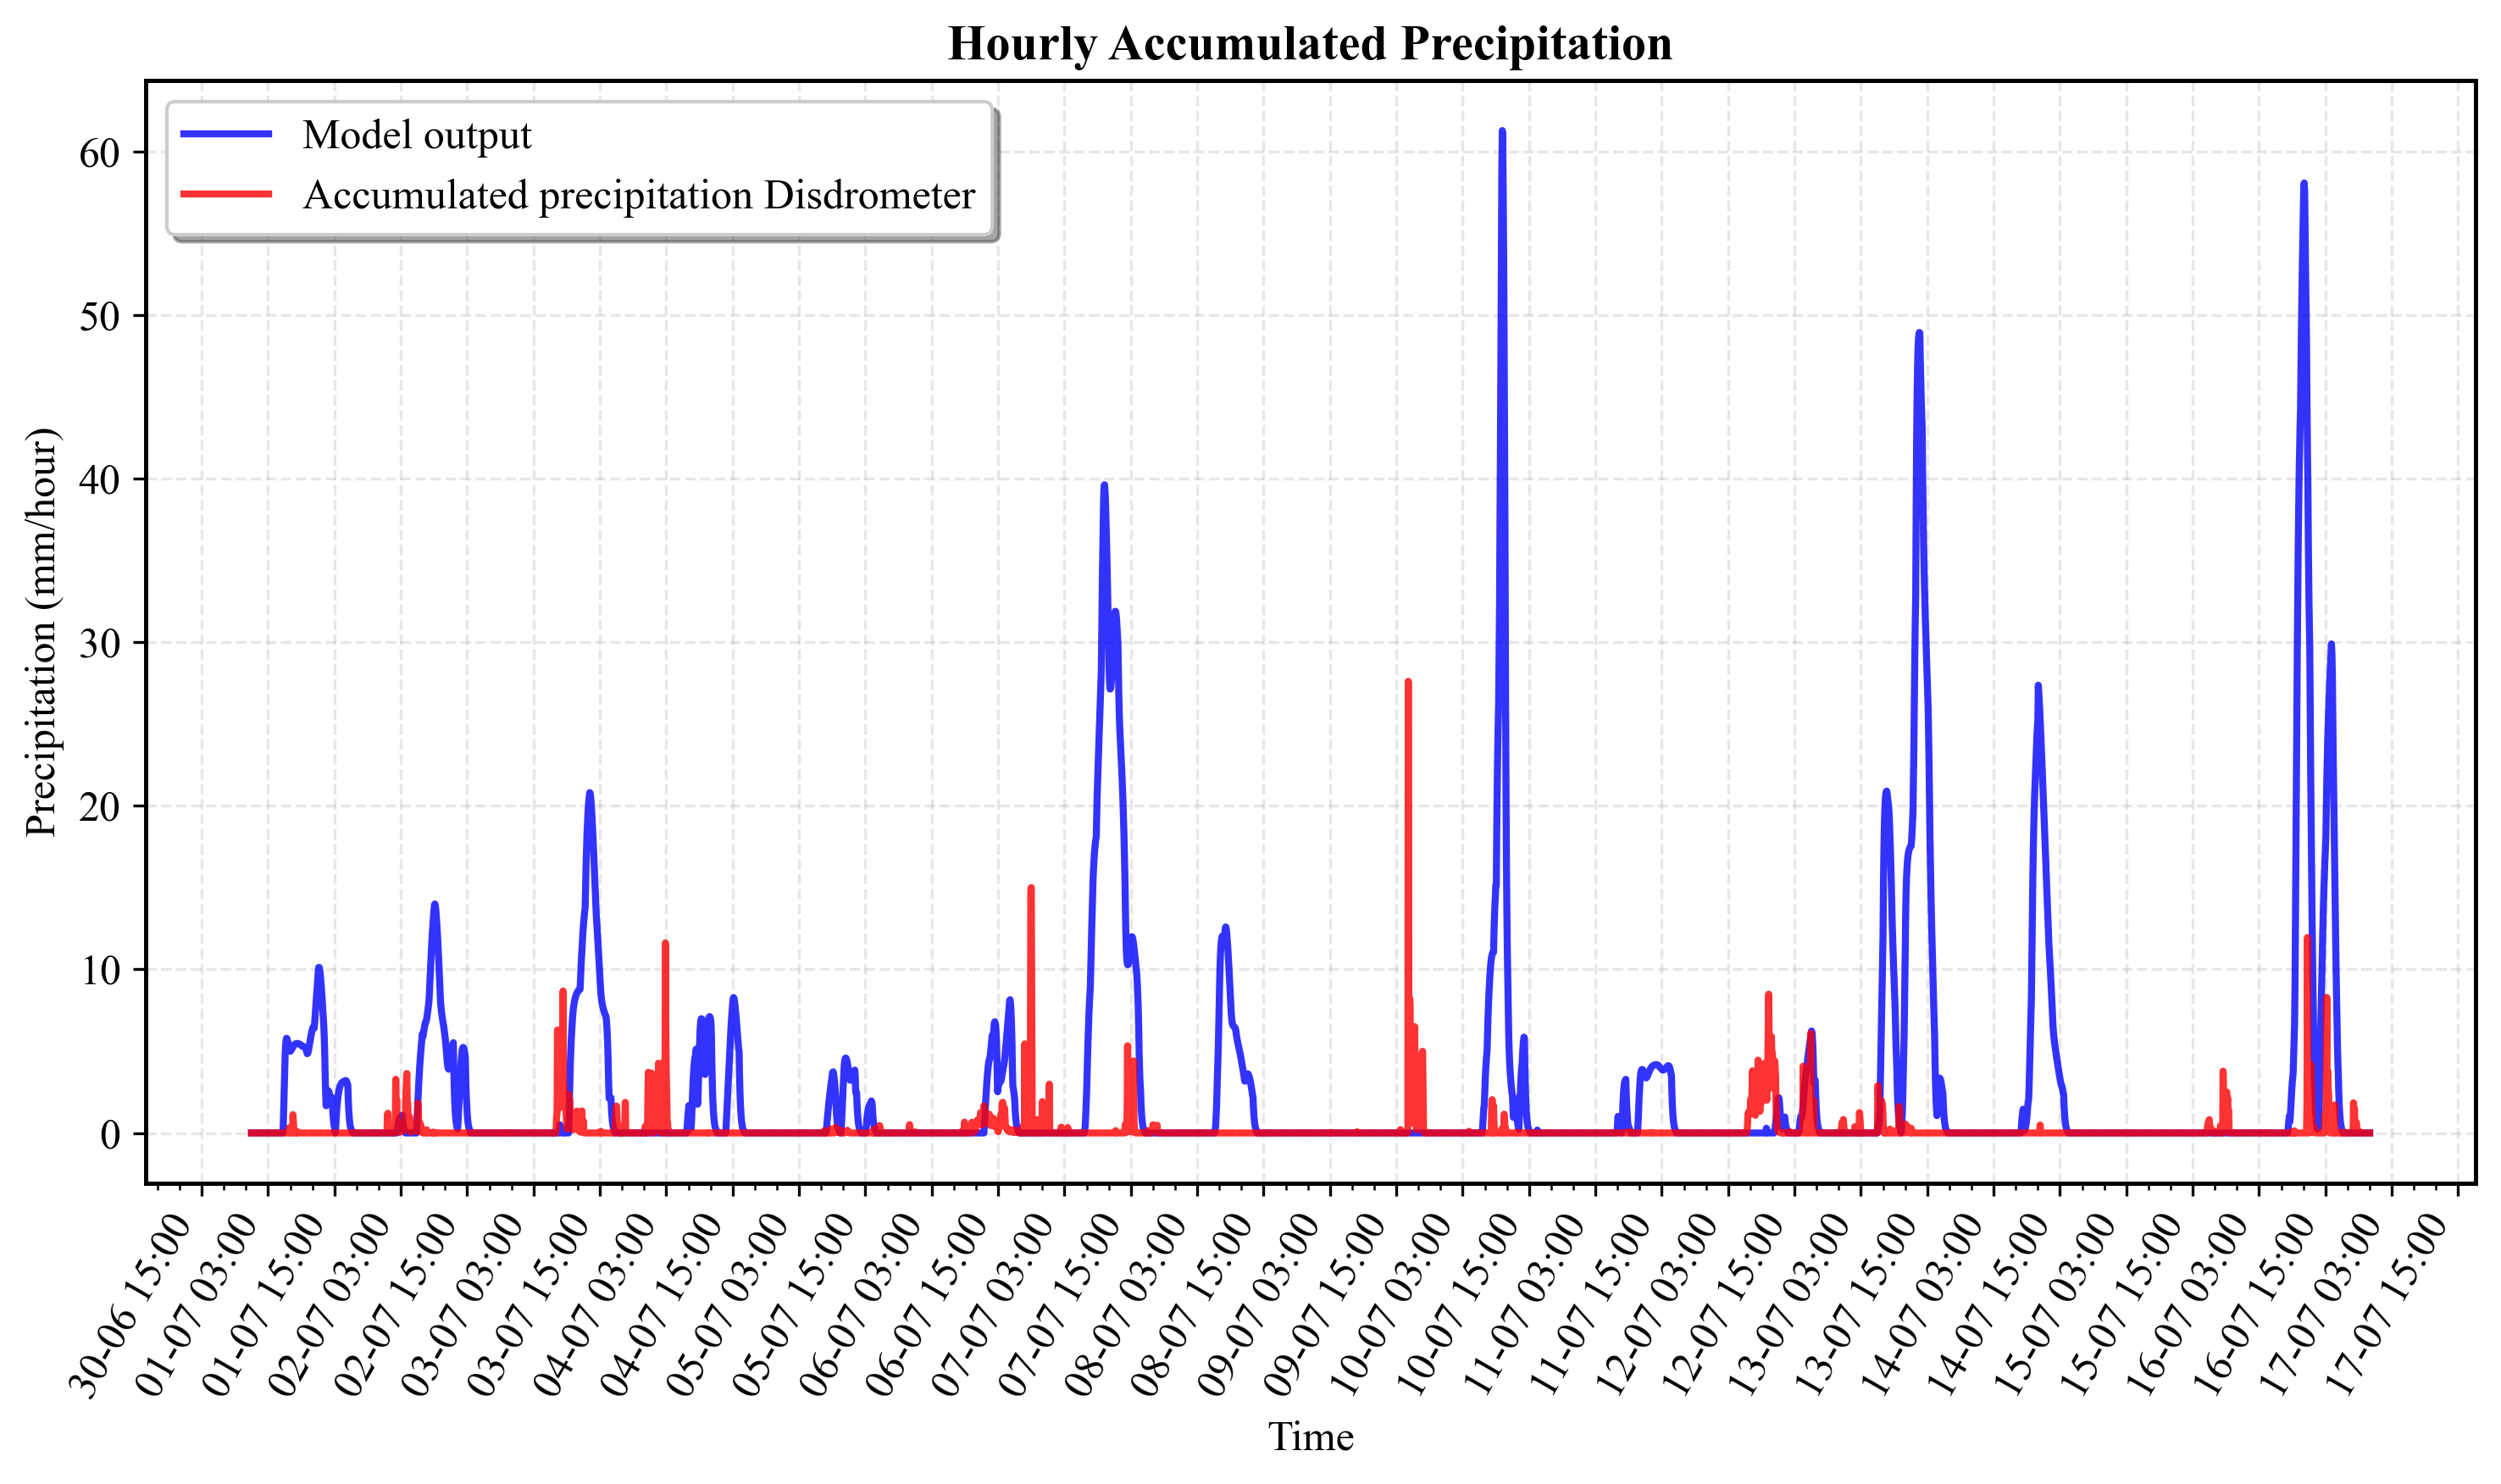

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create the plot with improved styling
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data with cleaner formatting
ax.plot(time, P * 3600, label='Model output', 
        color='blue', linewidth=2, alpha=0.8)
ax.plot(time, hourly_acc[:-11]/5, label='Accumulated precipitation Disdrometer', 
        color='red', linewidth=2, alpha=0.8)

# Add labels and title
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Precipitation (mm/hour)', fontsize=12)
ax.set_title('Hourly Accumulated Precipitation', fontsize=14, fontweight='bold')

# Format x-axis with dates
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(),
         rotation=rotation,
         ha='right',
         fontsize=12 * SCALE_FACTOR)

# Customize the legend
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

# Adjust layout and show
plt.tight_layout()
plt.show()